In [1]:
import pickle
import h5ify
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../main.mplstyle')

from bilby.core.result import read_in_result

from util import plot_corner
from util import plot_multiple
from util import param_to_label

%load_ext autoreload
%autoreload 2

# Comparison of sampling methods
(Here, I'm only showing for the simplest model---Jakob's spin model but with a $\texttt{Broken Power Law plus Two Peaks}$ mass model instead of the simple power law + peak.)

In [2]:
datadir = '../../data/inference/strong/multimass/noah/bpl2p'

In [3]:
## nested sampling w/ 1000 live points, `naccept=5`.
# merge 10 different realizations (different initial `sampling_seed`) by evidence reweighting
# NOTE: with static nested sampling we prioritize estimating prior weights for evidence estimation;
# estimated remainder in evidence is used to determine convergence.
merged = h5ify.load(f'{datadir}/sampling_seed/merged.h5')

In [4]:
## Sample with nested sampling, w/ 10,000 live points, `naccept=5`, and use prior in log_sigma_1, log_sigma_2, log_sigma_3.
# This may make it easier to estimate likelihood iso-contours
# (particularly since some combinations of weight_a, mu_i, and sigma_i are near the edge of the sigma_i prior for i = 1, 2, 3)
logsig = h5ify.load(f'{datadir}/log-sigma/var1/nlive/10000/posterior.h5')

for i in range(1, 4):
    logsig[f'sigma_{i}'] = np.exp(logsig[f'log_sigma_{i}'])

# reweight from uniform prior in log-sigma to a uniform prior in sigma.
log_weights = np.sum([ logsig[f'log_sigma_{i}'] for i in range(1, 4) ], axis=0)

rng = np.random.default_rng(12413)
weights = np.exp(log_weights)
keep = weights > rng.uniform(0, max(weights), len(weights))

logsig = {k : v[keep] for k, v in logsig.items() if len(np.atleast_1d(v)) > 1}

In [9]:
## Hybrid ptemcee; initialize `ptemcee` from one of the nested sampling runs 
ptemcee = h5ify.load(f'{datadir}/ptemcee-hybrid-var1/posterior.h5')

# load in the checkpoint file to check convergence criterion
with open(f'{datadir}/ptemcee-hybrid-var1/run_checkpoint_resume.pickle', 'rb') as f:
    ptemcee_checkpoint = pickle.load(f)

# NOTE: convergence with ptemcee is determined by the inter- and intra-chain variance
# characterized by Q (similar to the Gelman-Rubin statistic)
# Q ~ 1 indicates convergence
print('ptemcee achieved Q:', ptemcee_checkpoint['Q_list'][-1])

ptemcee achieved Q: 1.0054756912474372


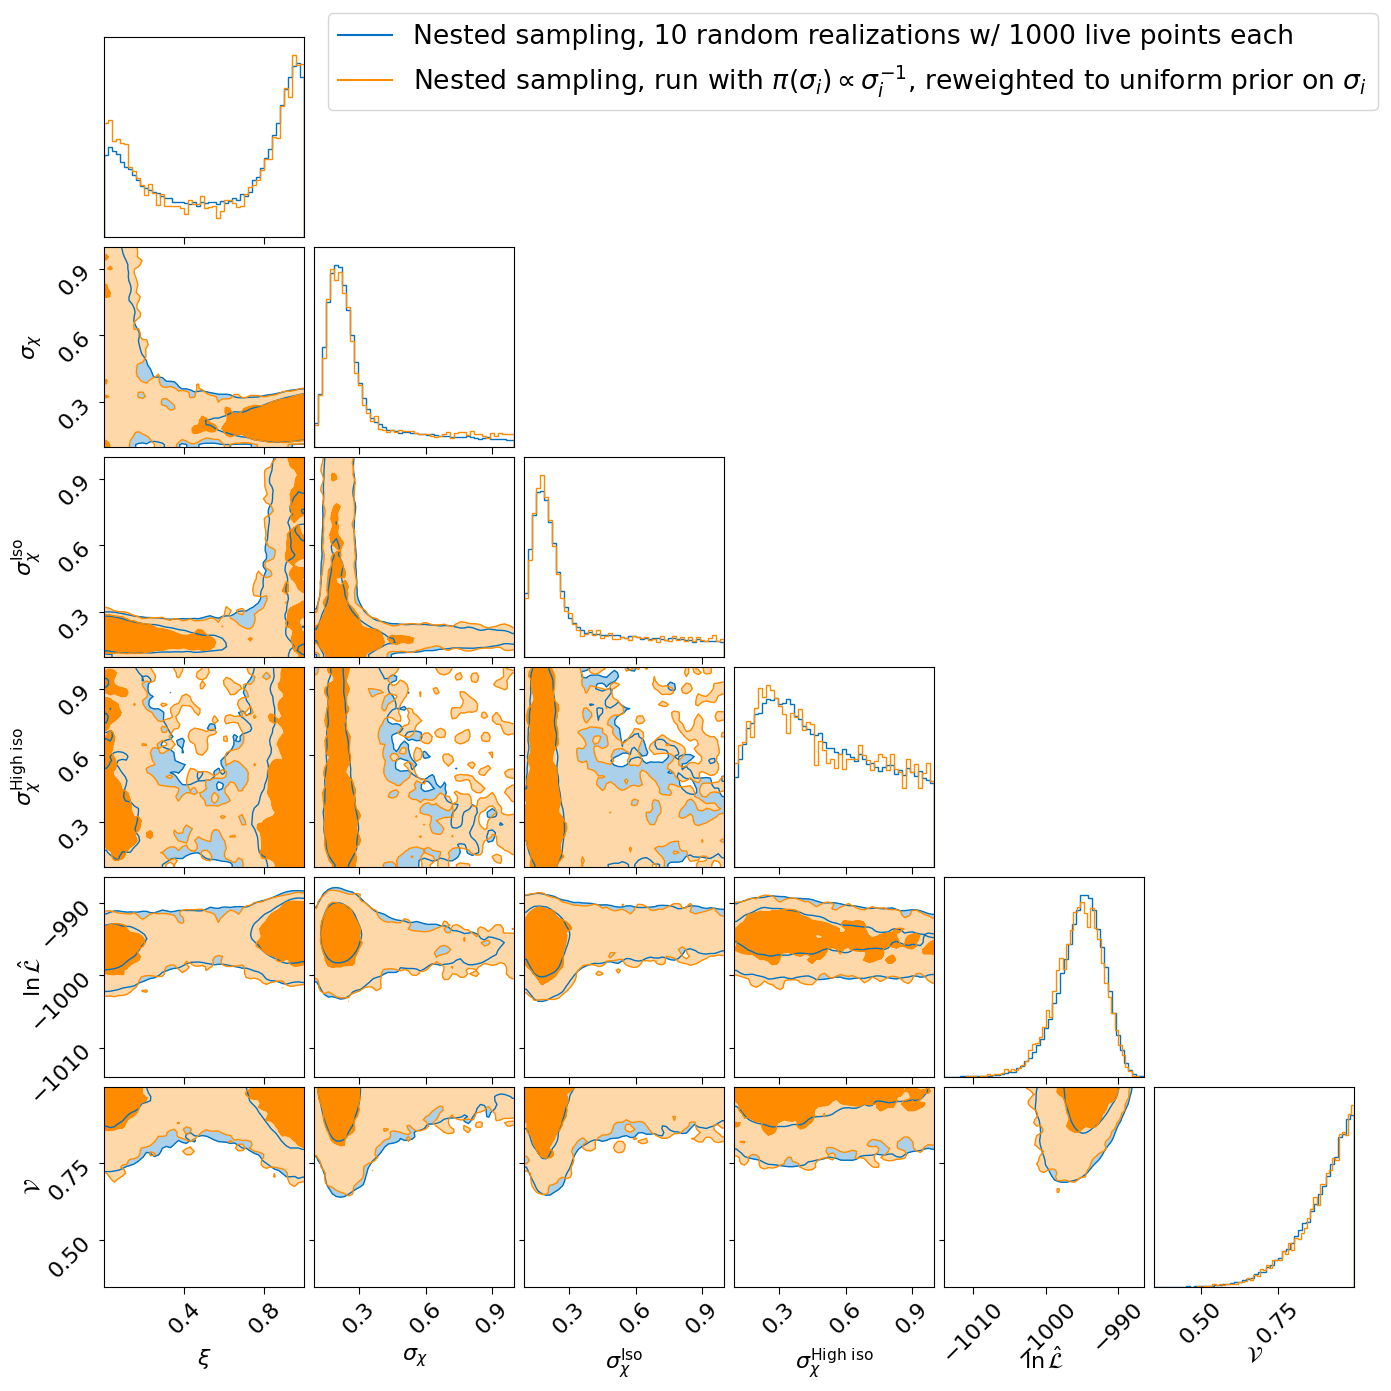

In [6]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_multiple(
    [merged, logsig],
    labels={k : v for k, v in param_to_label.items() if k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Nested sampling, run with $\pi(\sigma_{i}) \propto \sigma_i^{-1}$, reweighted to uniform prior on $\sigma_i$'
    ],
)

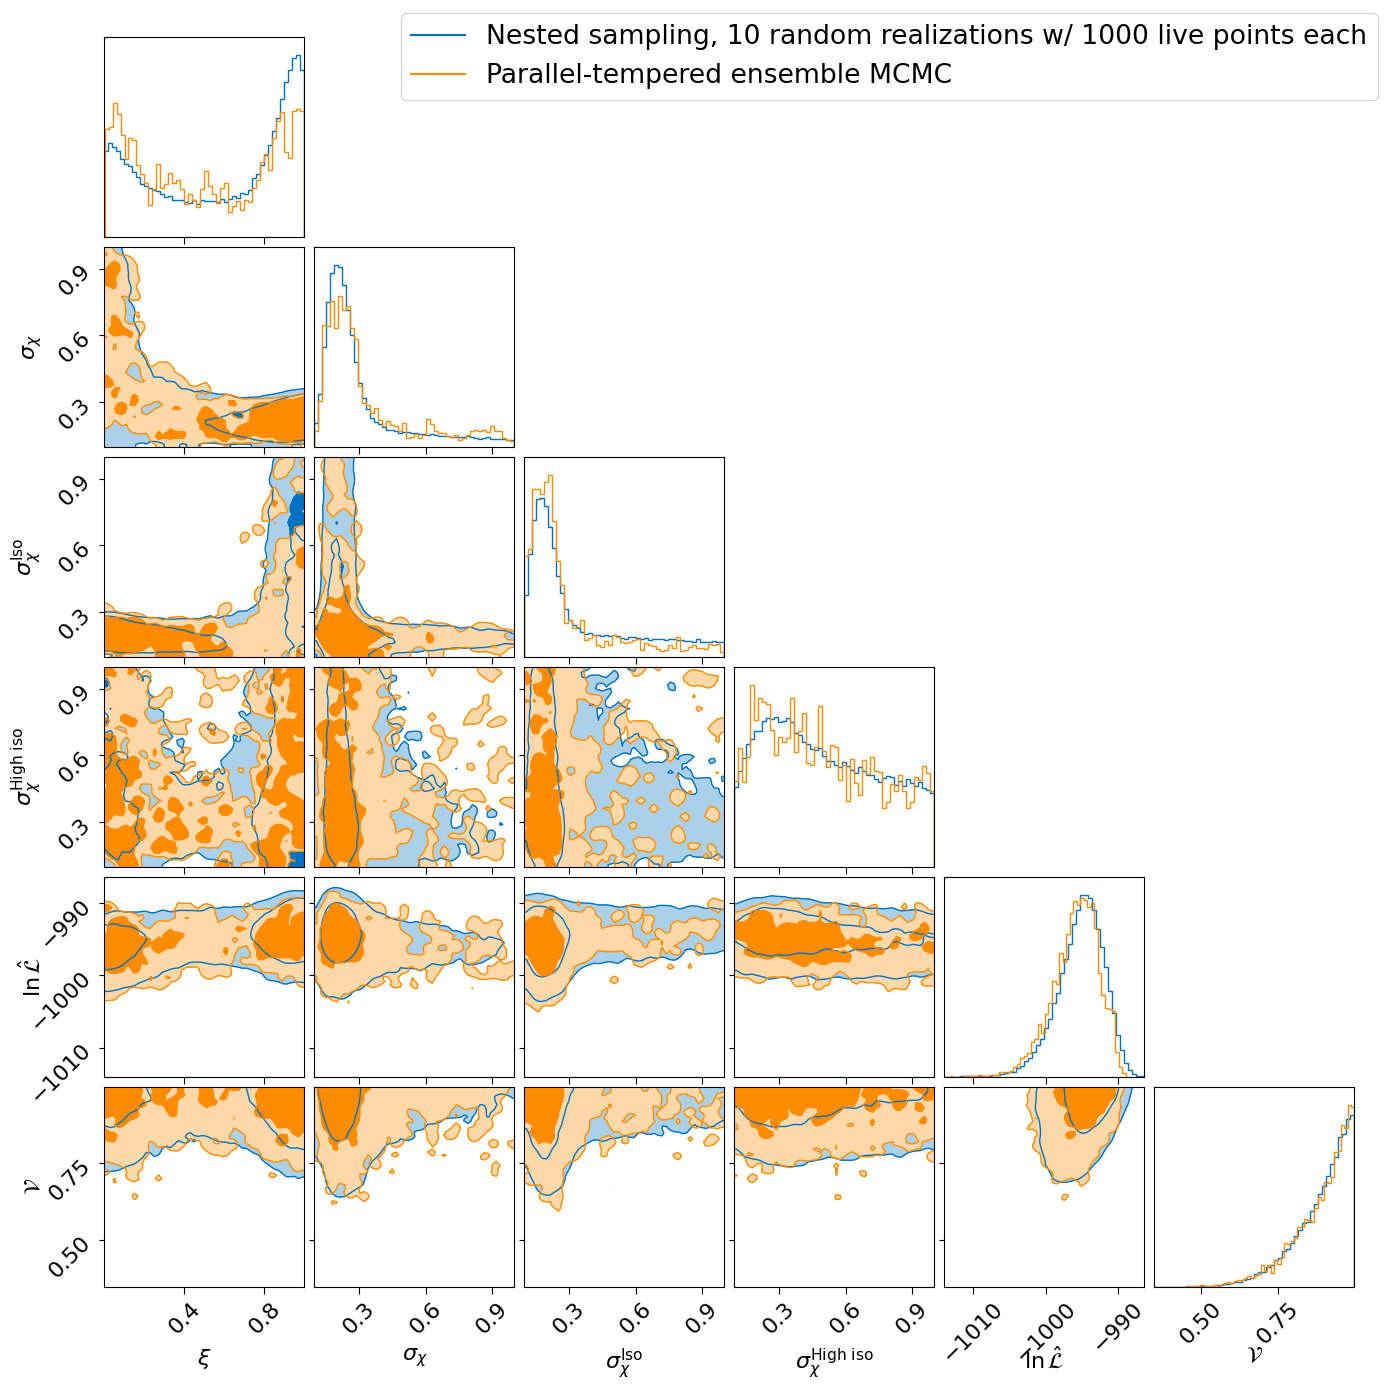

In [10]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_multiple(
    [merged, ptemcee],
    labels={k : v for k, v in param_to_label.items() if k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

How does the variance threshold impact these results?

In [11]:
# We also ran ptemcee with var < 5 as opposed to var. < 1
ptemcee_var5 = h5ify.load(f'{datadir}/ptemcee-hybrid-var5/posterior.h5')

# load in the checkpoint file to check convergence criterion
with open(f'{datadir}/ptemcee-hybrid-var5/run_checkpoint_resume.pickle', 'rb') as f:
    ptemcee_checkpoint = pickle.load(f)

# NOTE: convergence with ptemcee is determined by the inter- and intra-chain variance
# characterized by Q (similar to the Gelman-Rubin statistic)
# Q ~ 1 indicates convergence
print('ptemcee achieved Q:', ptemcee_checkpoint['Q_list'][-1])

ptemcee achieved Q: 1.0016836221365308


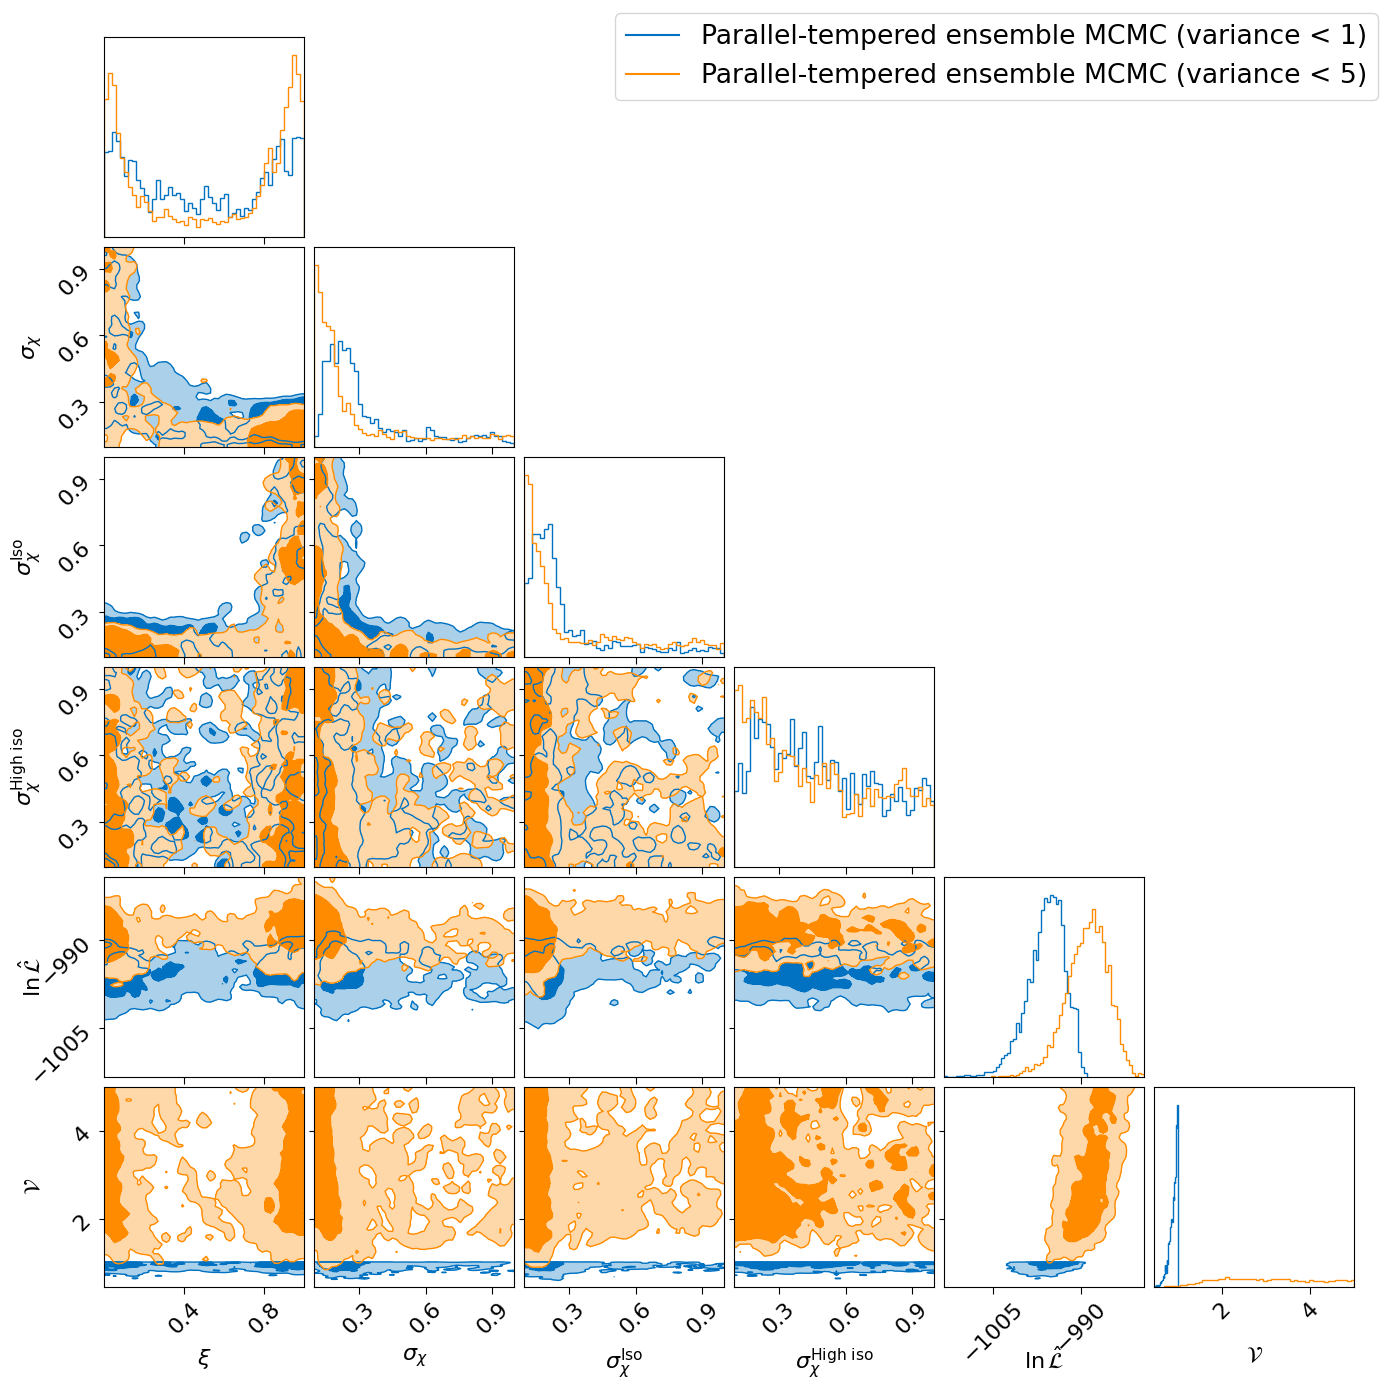

In [13]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_multiple(
    [ptemcee, ptemcee_var5],
    labels={k : v for k, v in param_to_label.items() if k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Parallel-tempered ensemble MCMC (variance < 1)',
        'Parallel-tempered ensemble MCMC (variance < 5)'
    ],
)

# Inspecting results

Here, I use the log-sigma nested sampling results since they had the most live points, and were consistent w/ the 10 variations of 1000 live point runs.

## One smoothed, broken power law + 2 peaks mass model for all subpopulations

In [2]:
datadir = '../../data/inference/strong/multimass/noah/bpl2p'

## Sample with nested sampling, w/ 10,000 live points, `naccept=5`, and use prior in log_sigma_1, log_sigma_2, log_sigma_3.
# This may make it easier to estimate likelihood iso-contours
# (particularly since some combinations of weight_a, mu_i, and sigma_i are near the edge of the sigma_i prior for i = 1, 2, 3)
logsig = h5ify.load(f'{datadir}/log-sigma/var1/nlive/10000/posterior.h5')

for i in range(1, 4):
    logsig[f'sigma_{i}'] = np.exp(logsig[f'log_sigma_{i}'])

# reweight from uniform prior in log-sigma to a uniform prior in sigma.
log_weights = np.sum([ logsig[f'log_sigma_{i}'] for i in range(1, 4) ], axis=0)

rng = np.random.default_rng(12413)
weights = np.exp(log_weights)
keep = weights > rng.uniform(0, max(weights), len(weights))

logsig = {k : v[keep] for k, v in logsig.items() if len(np.atleast_1d(v)) > 1}

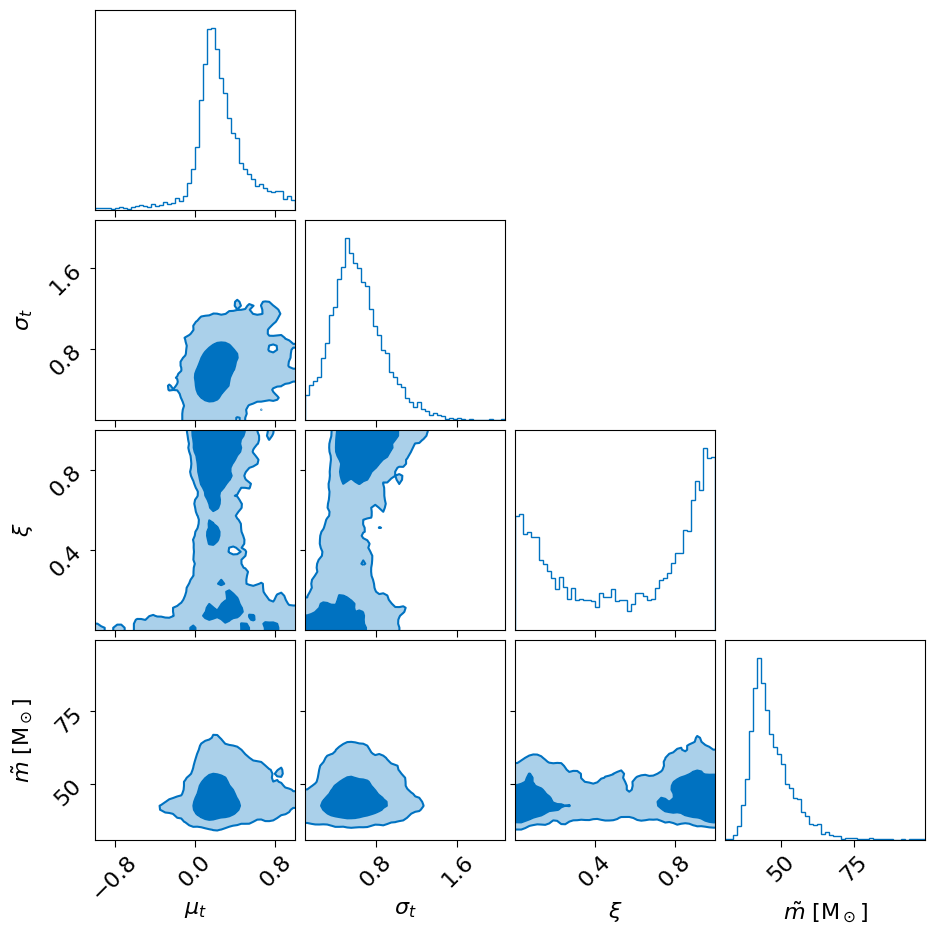

In [7]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut']

fig = plot_corner(
    logsig,
    labels={k : param_to_label[k] for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

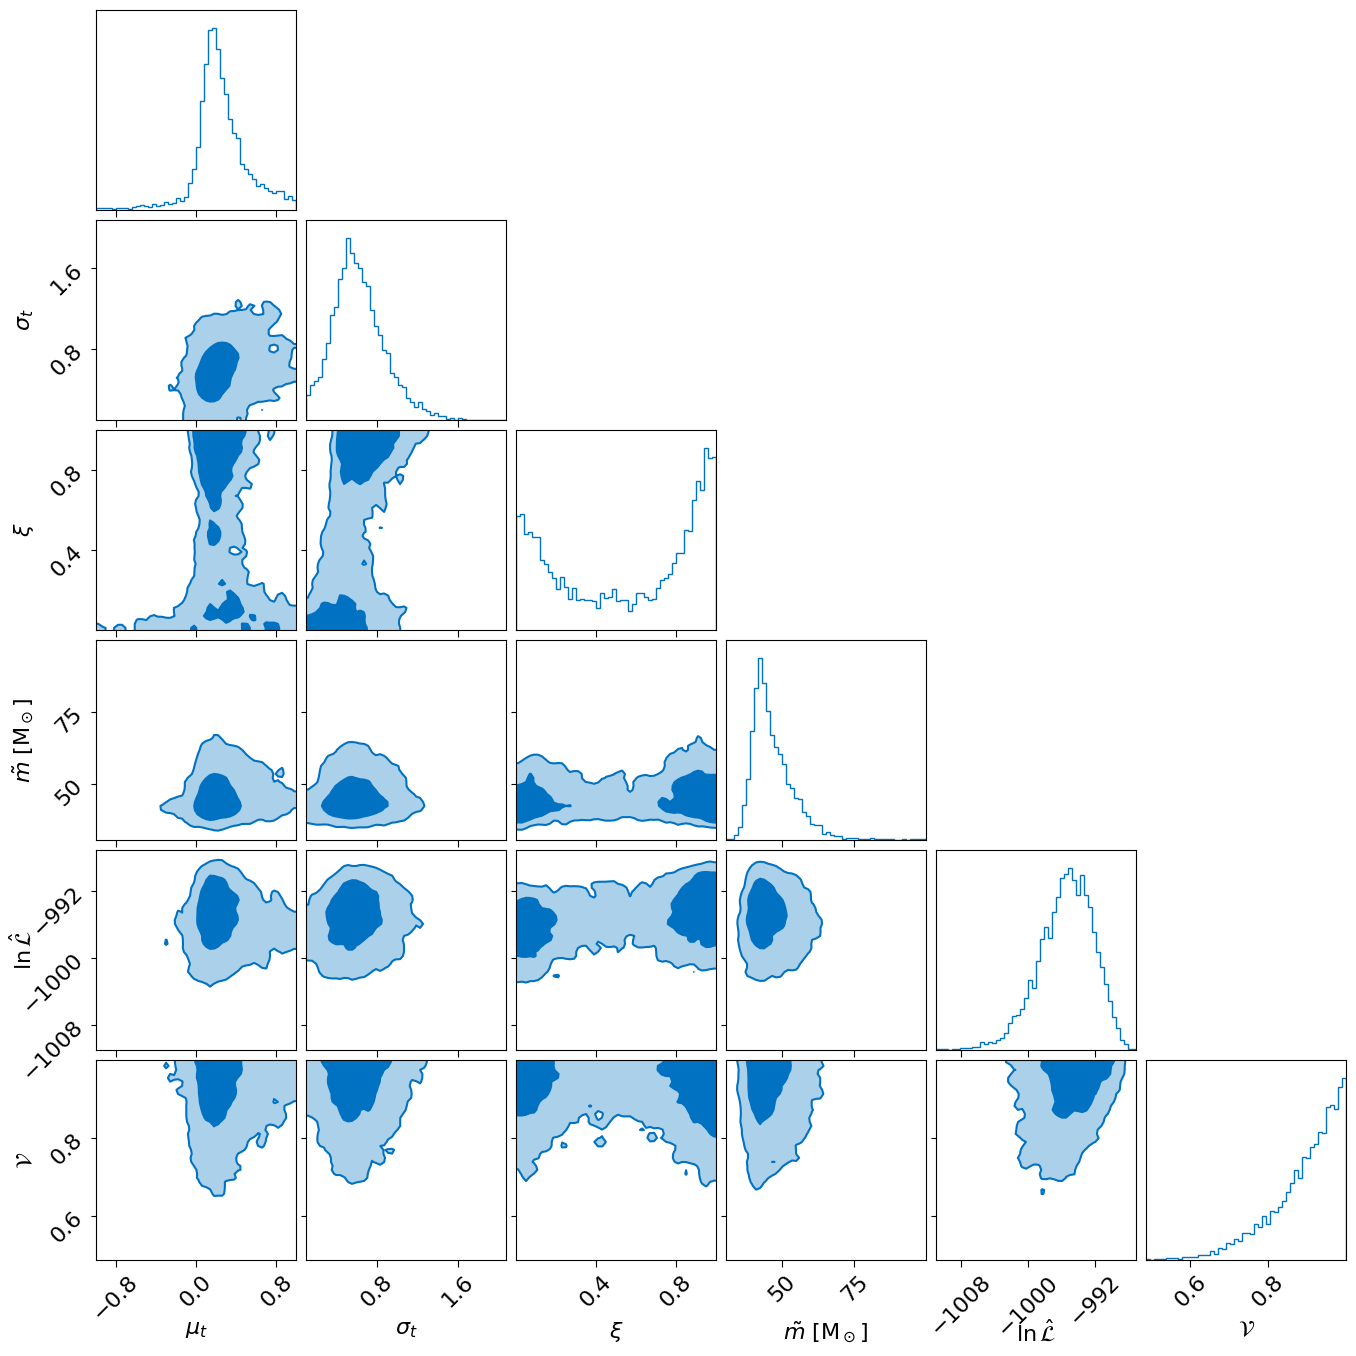

In [4]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut', 'log_likelihood', 'variance']

fig = plot_corner(
    logsig,
    labels={k : param_to_label[k] for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

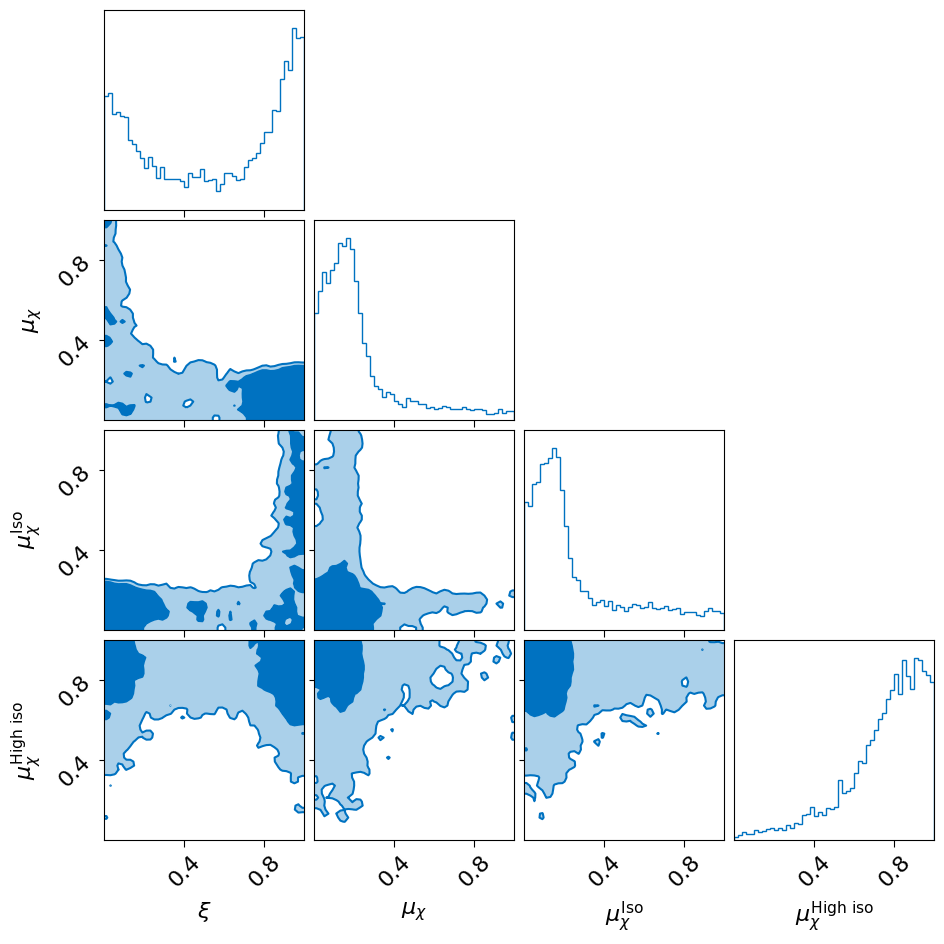

In [8]:
keys = ['weight_a', 'mu_1', 'mu_2', 'mu_3']

fig = plot_corner(
    logsig,
    labels={k : param_to_label[k] for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

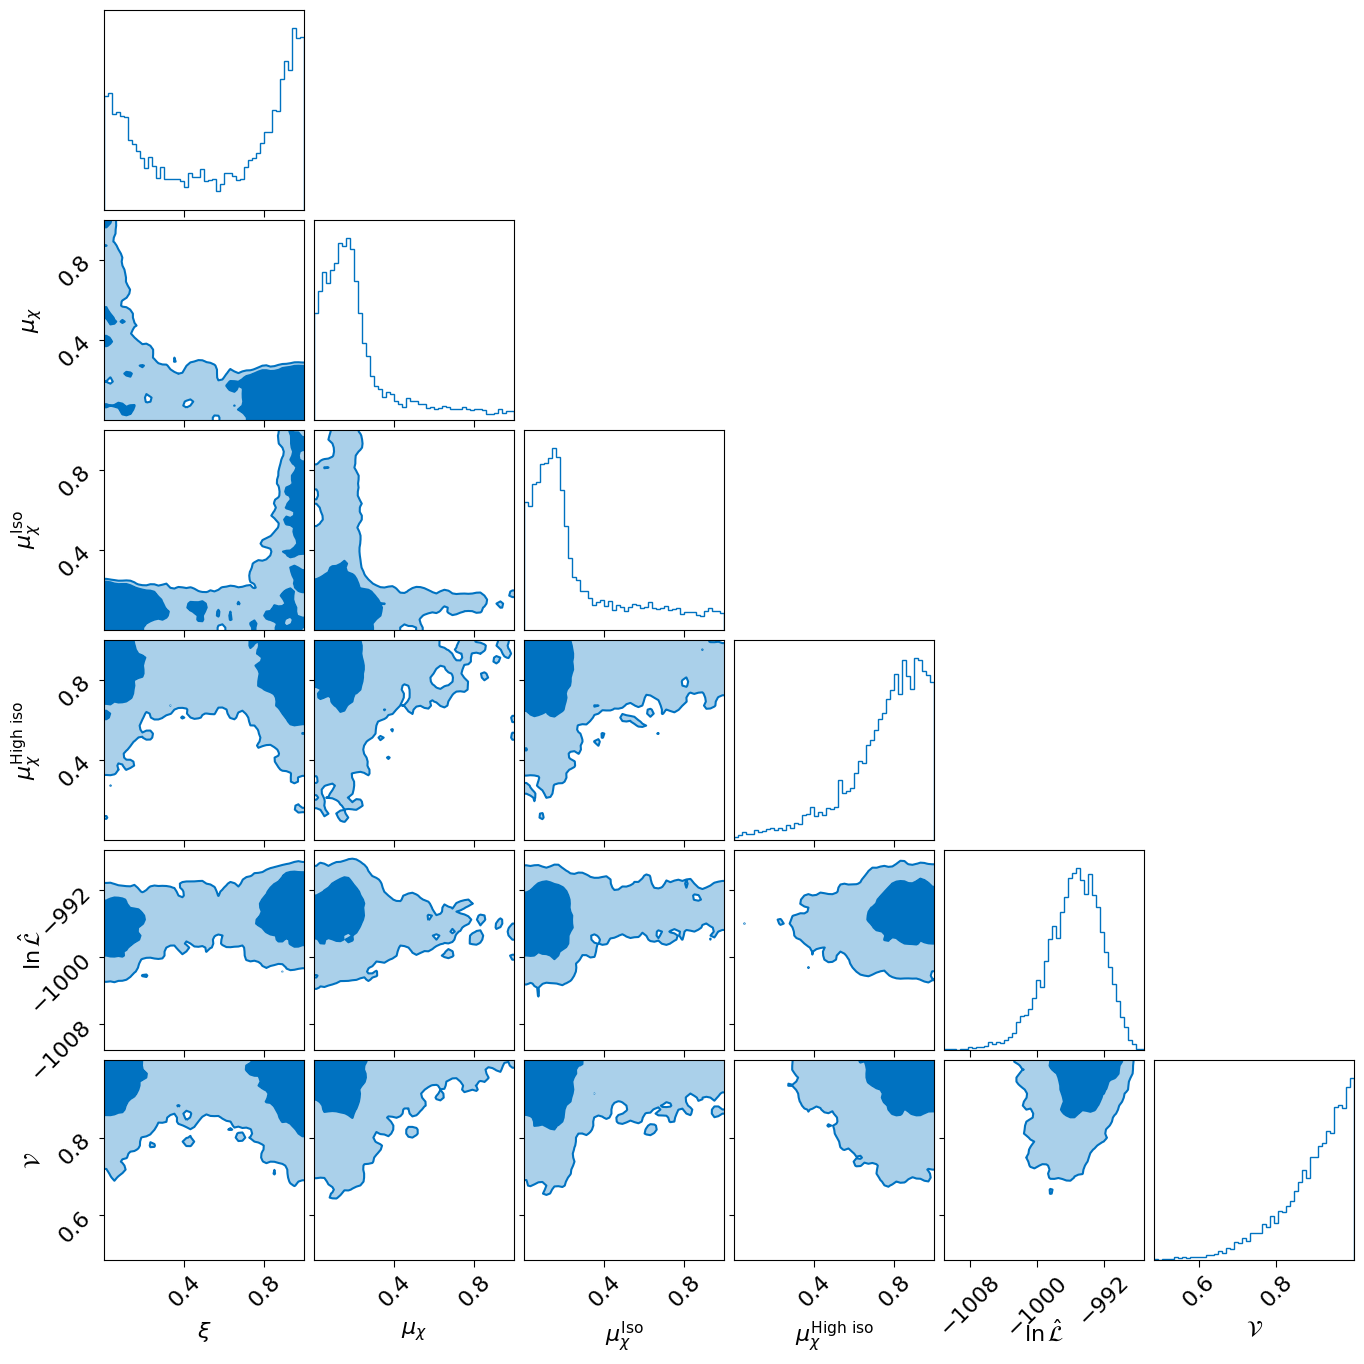

In [5]:
keys = ['weight_a', 'mu_1', 'mu_2', 'mu_3', 'log_likelihood', 'variance']

fig = plot_corner(
    logsig,
    labels={k : param_to_label[k] for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

## Two mass models

- Each subpopulation with an isotropic tilt distribution shares a mass distribution
- The subpopulation with a truncated normal tilt distributions has a different mass distribution

Both mass distributions taken the functional form of the $\texttt{Broken power law plus two peaks}$.

In [21]:
datadir = '../../data/inference/strong/multimass/noah/twomass'
twomass = h5ify.load(f'{datadir}/sampling_seed/merged.h5')

twomass_pt = h5ify.load(f'{datadir}/ptemcee-hybrid-var1/posterior.h5')

# load in the checkpoint file to check convergence criterion
with open(f'{datadir}/ptemcee-hybrid-var1/run_checkpoint_resume.pickle', 'rb') as f:
    ptemcee_checkpoint = pickle.load(f)

# NOTE: convergence with ptemcee is determined by the inter- and intra-chain variance
# characterized by Q (similar to the Gelman-Rubin statistic)
# Q ~ 1 indicates convergence
print('ptemcee achieved Q:', ptemcee_checkpoint['Q_list'][-1])

ptemcee achieved Q: 1.0031654192128627


Based on the plot below, it's clear the MCMC is *not* converged, despite what Q says. Possible we need to tune other convergence criteria like the maximum allowed autocorrelation time, or just run with more walkers.

However, this run is still useful because we do pick up a mode in $\xi$ spin near 1 with slightly higher likelihood than at $\xi \sim 0$.

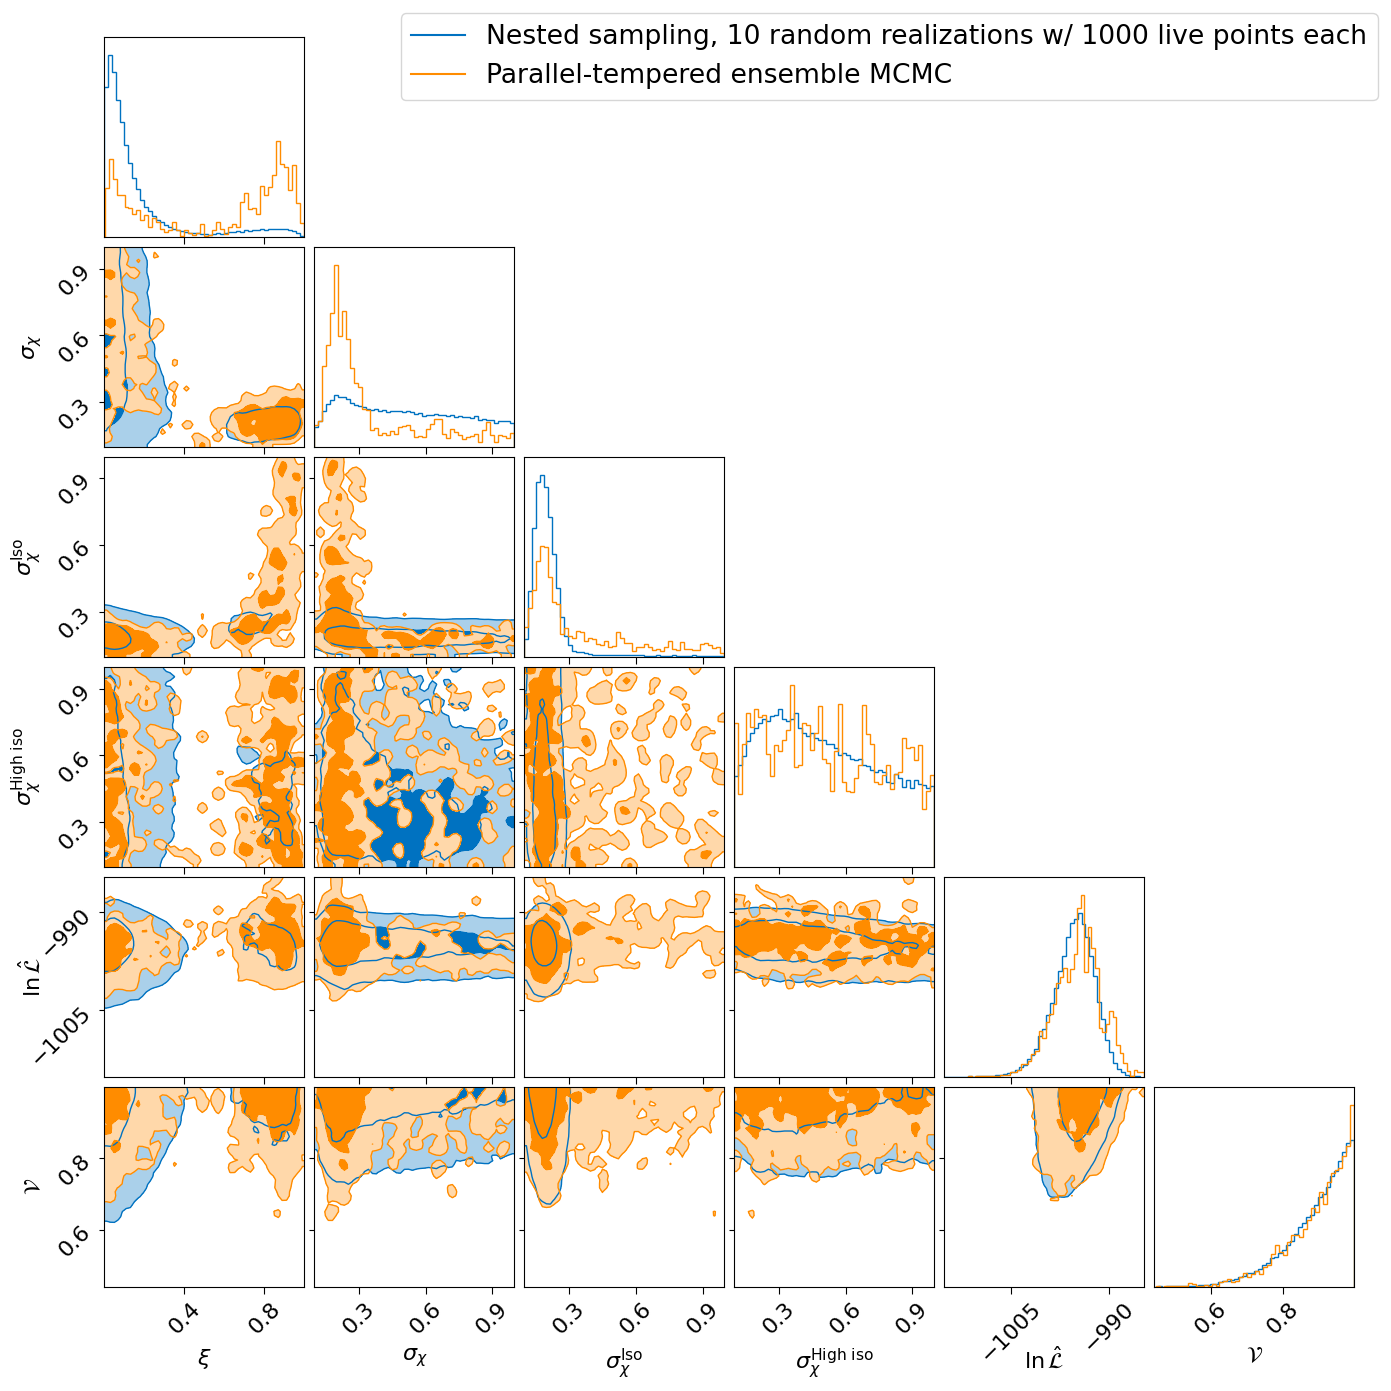

In [20]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_multiple(
    [twomass, twomass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

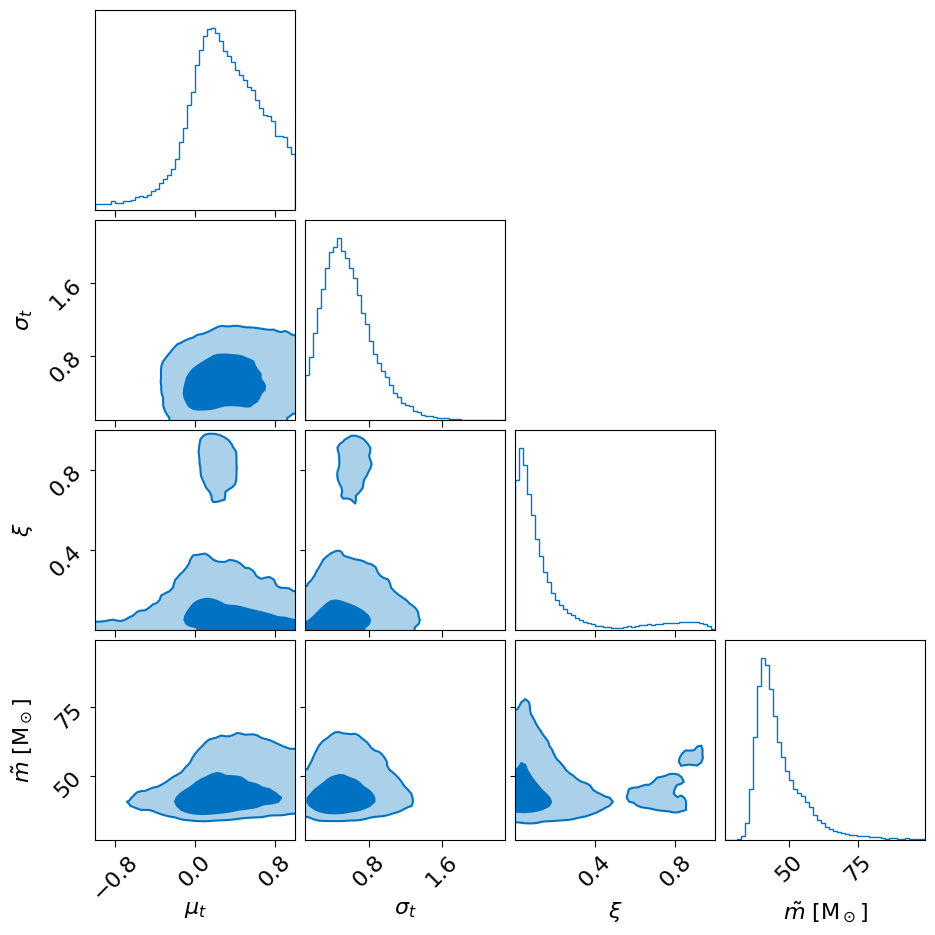

In [14]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut']

fig = plot_corner(
    twomass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

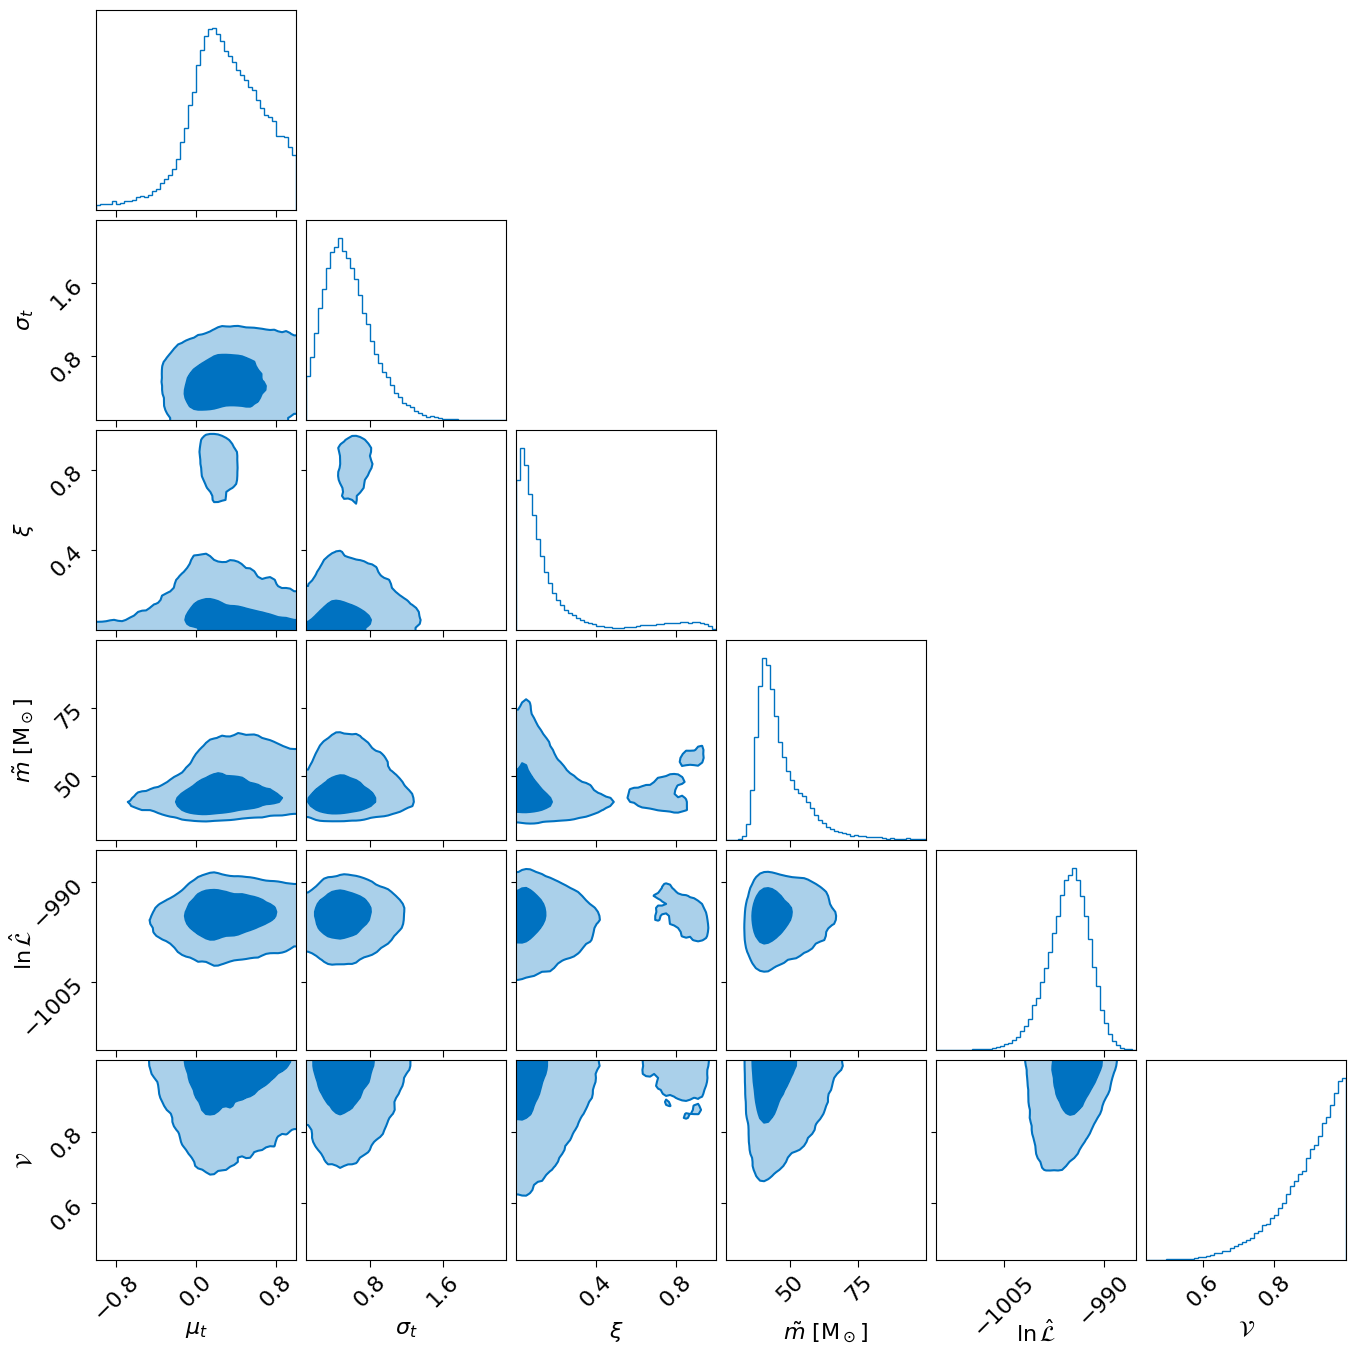

In [15]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut', 'log_likelihood', 'variance']

fig = plot_corner(
    twomass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

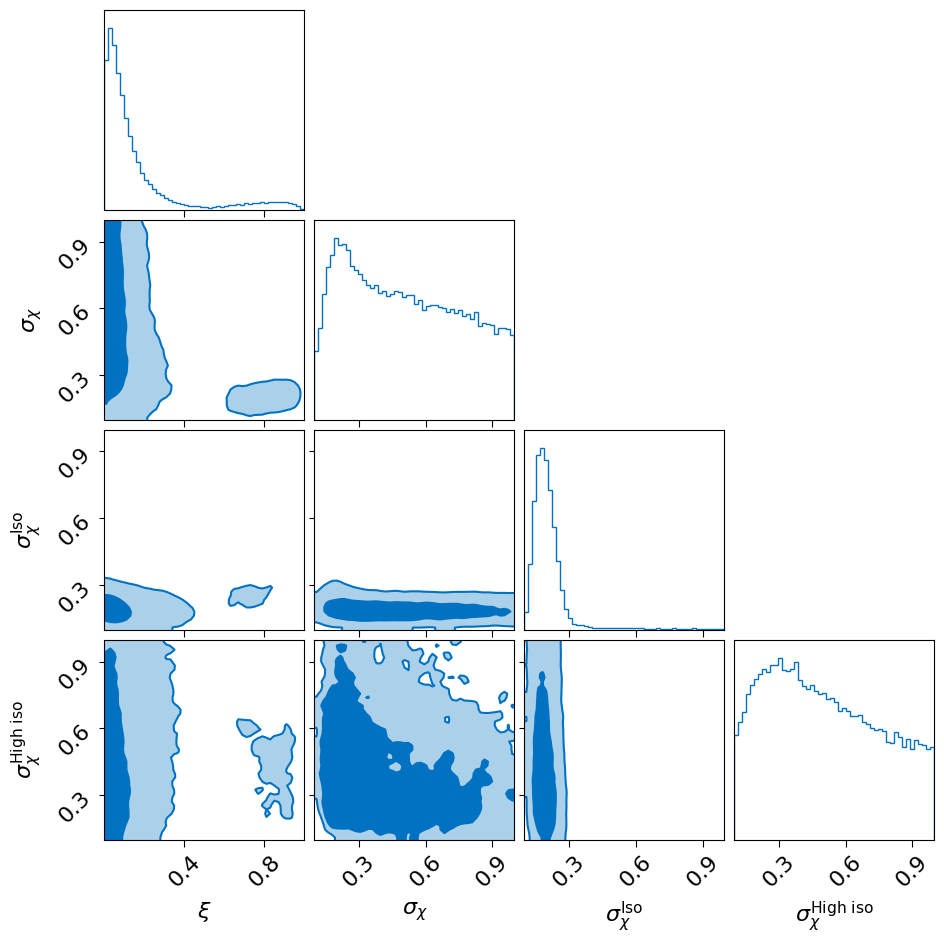

In [16]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3']

fig = plot_corner(
    twomass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

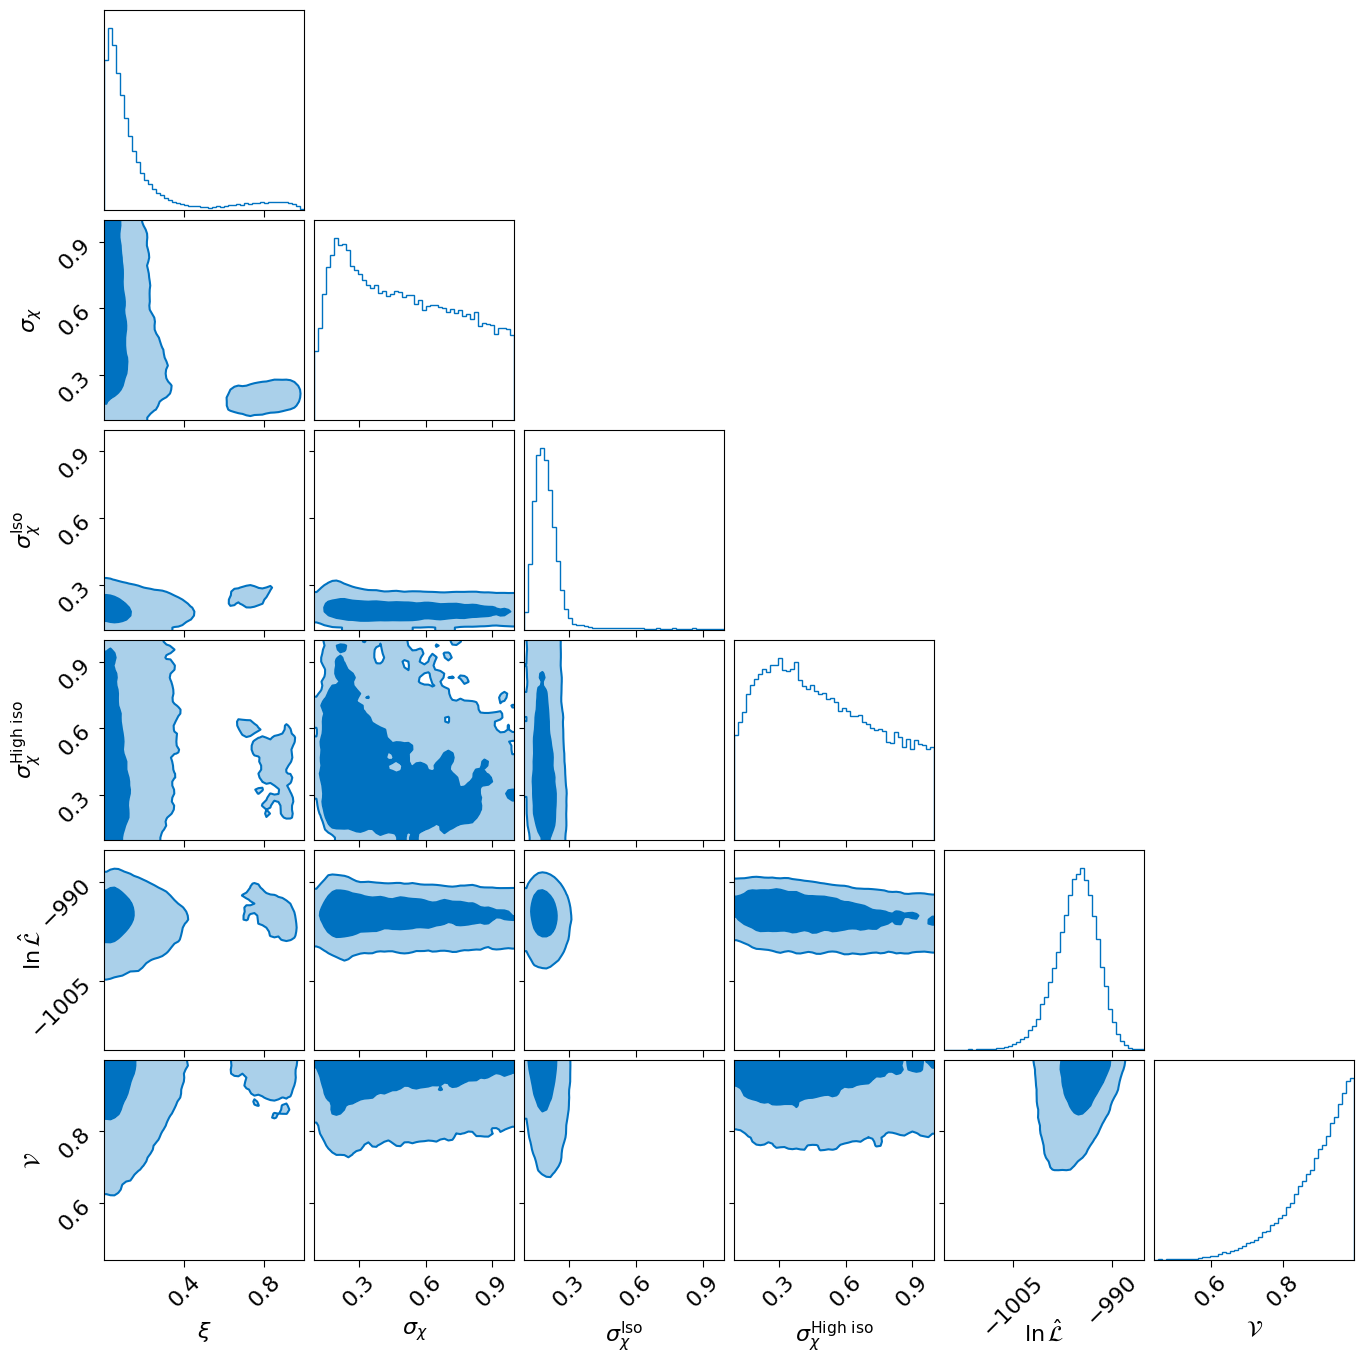

In [17]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_corner(
    twomass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

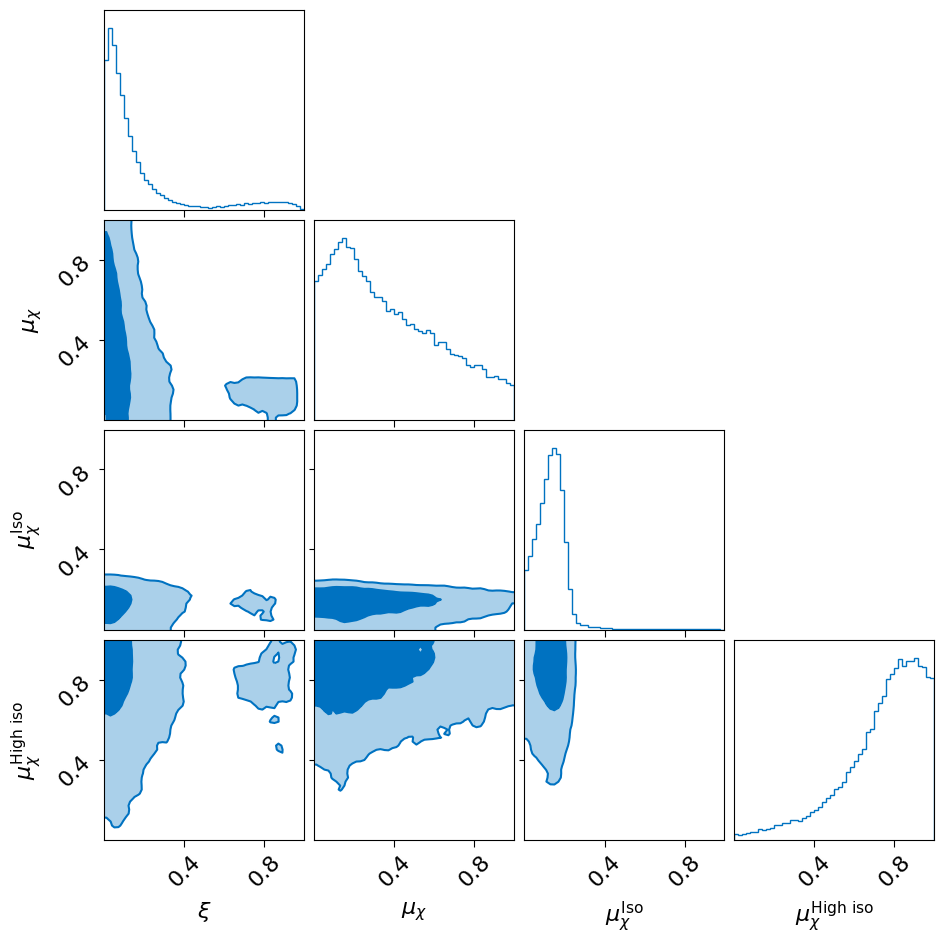

In [22]:
keys = ['weight_a', 'mu_1', 'mu_2', 'mu_3']

fig = plot_corner(
    twomass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

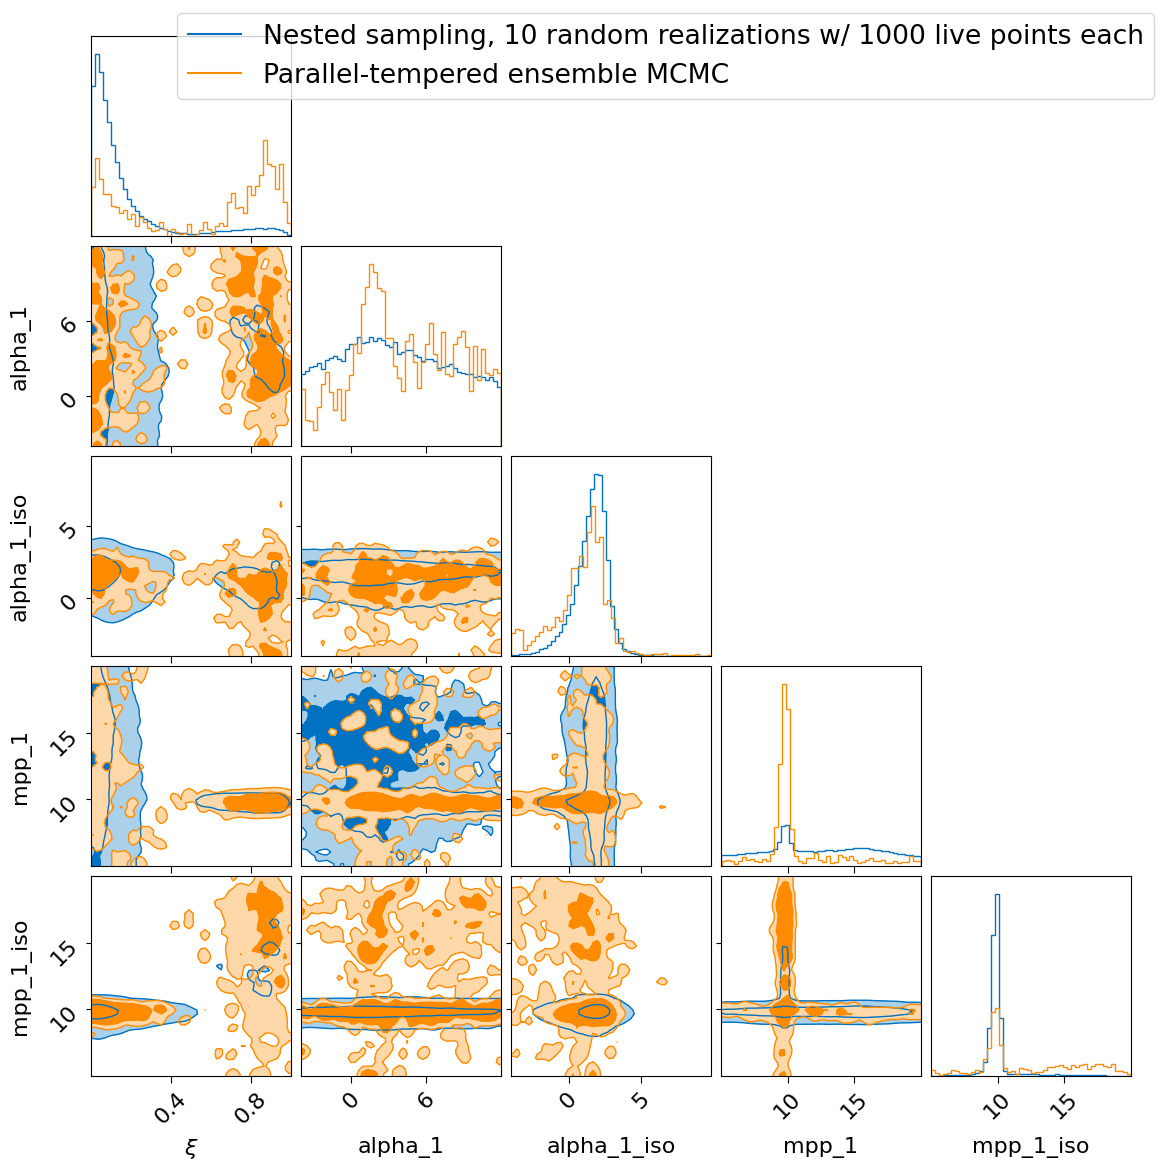

In [27]:
keys = ['weight_a', 'alpha_1', 'alpha_1_iso', 'mpp_1', 'mpp_1_iso']

fig = plot_multiple(
    [twomass, twomass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

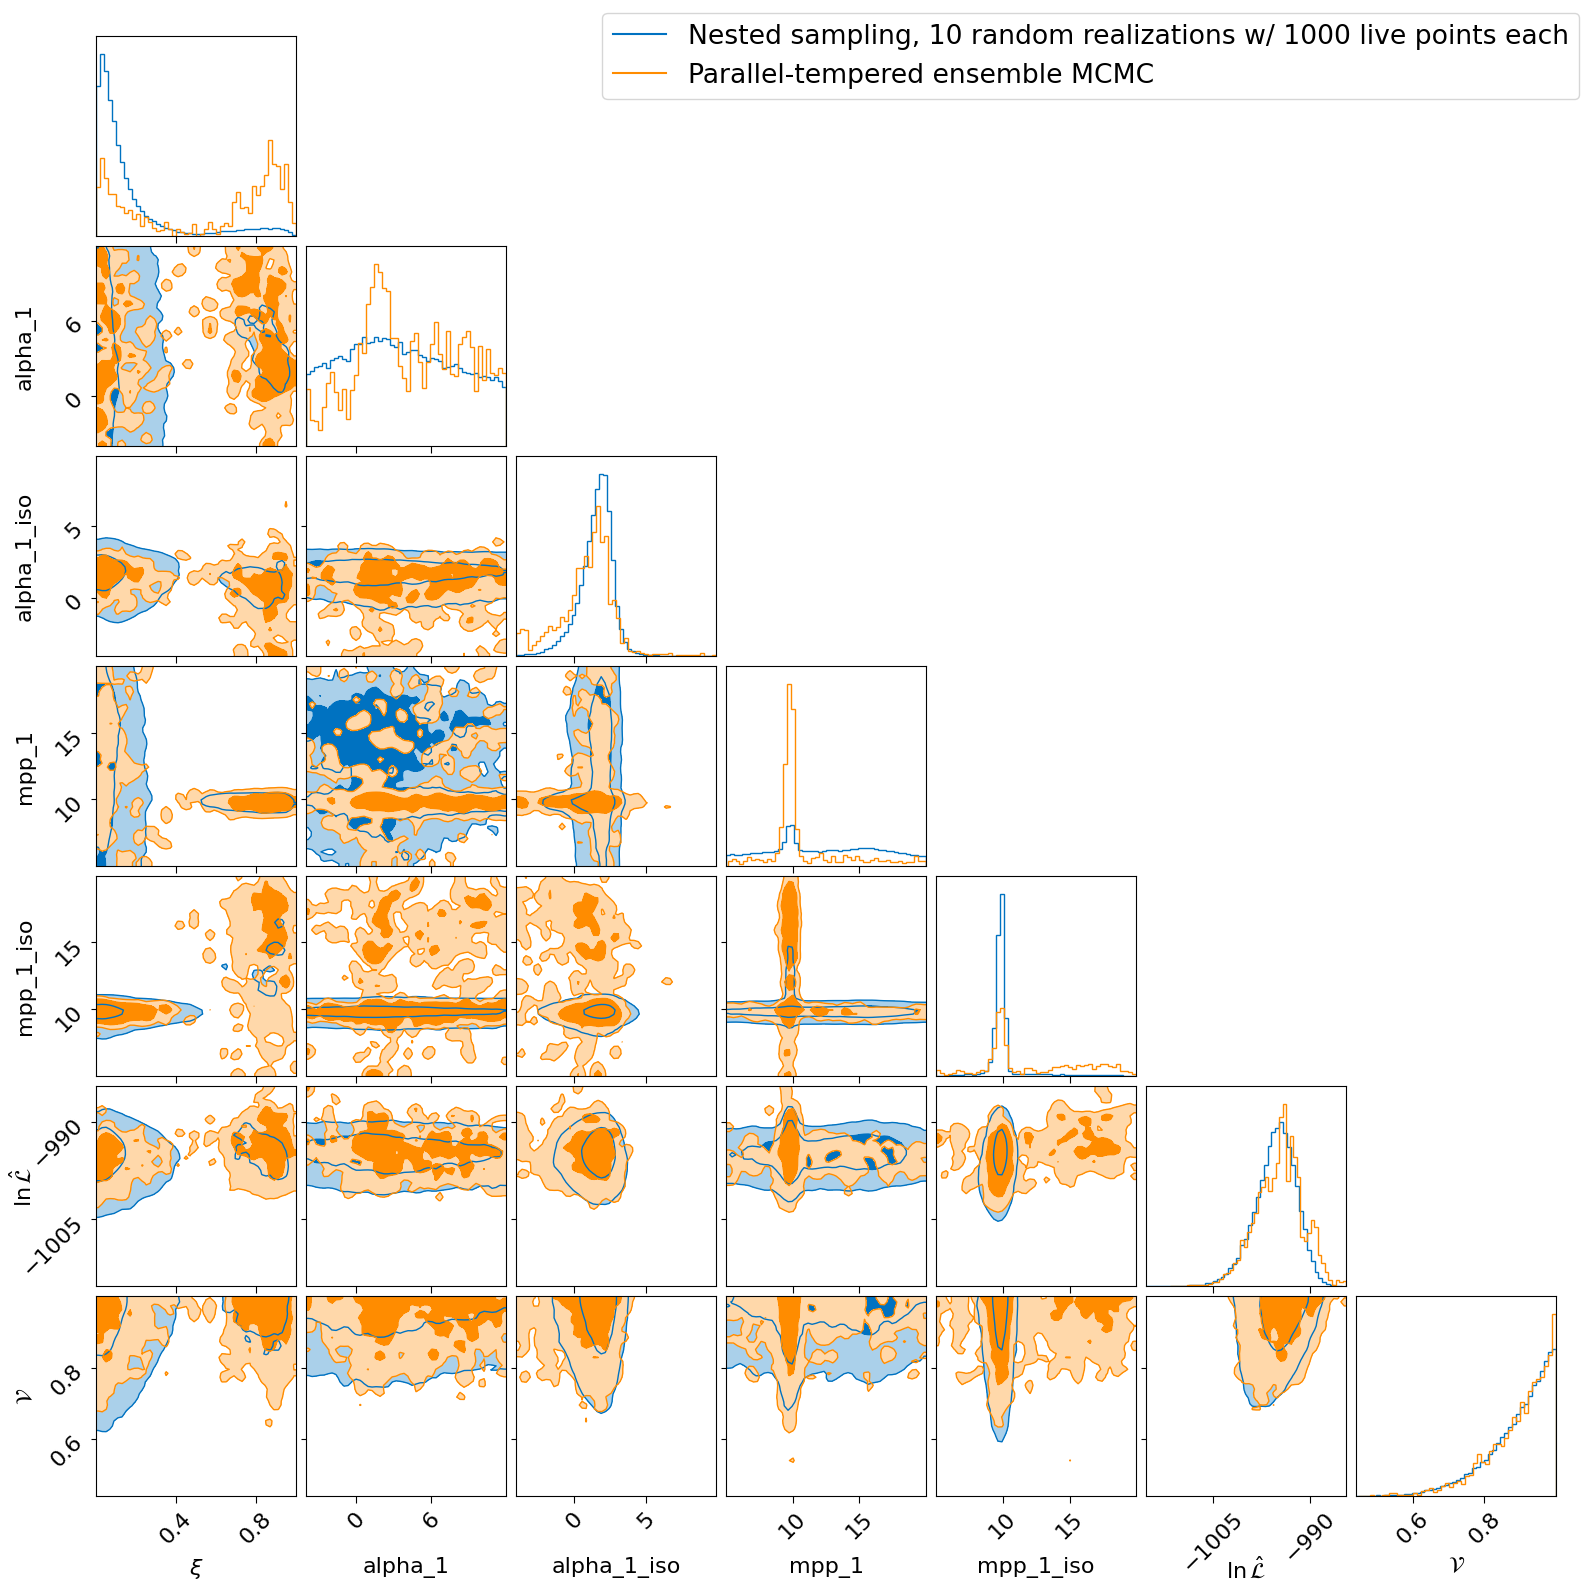

In [29]:
keys = ['weight_a', 'alpha_1', 'alpha_1_iso', 'mpp_1', 'mpp_1_iso', 'log_likelihood', 'variance']

fig = plot_multiple(
    [twomass, twomass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

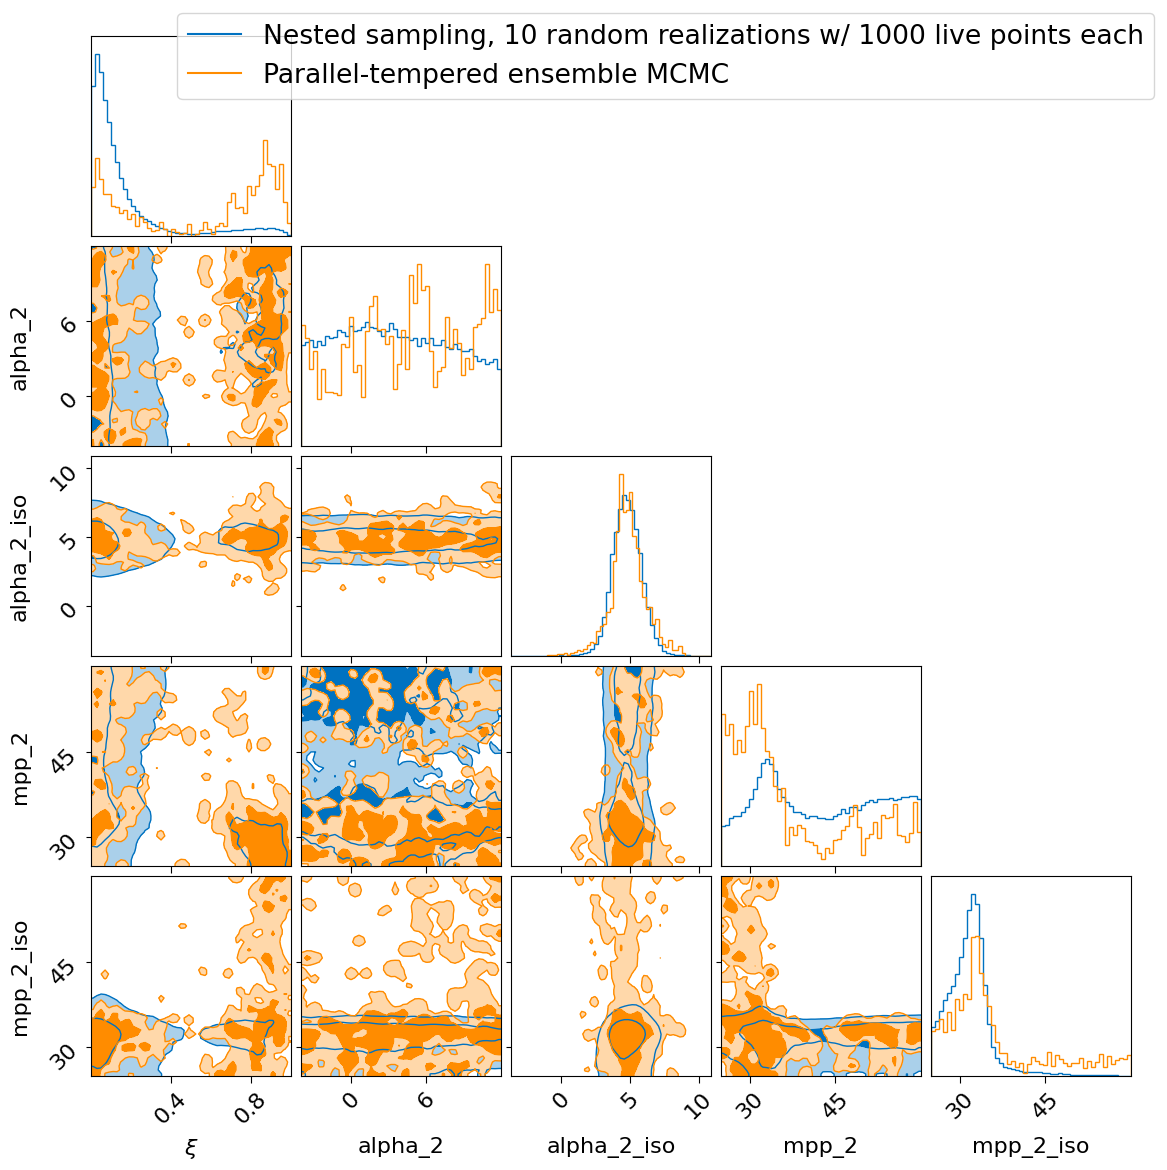

In [28]:
keys = ['weight_a', 'alpha_2', 'alpha_2_iso', 'mpp_2', 'mpp_2_iso']

fig = plot_multiple(
    [twomass, twomass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

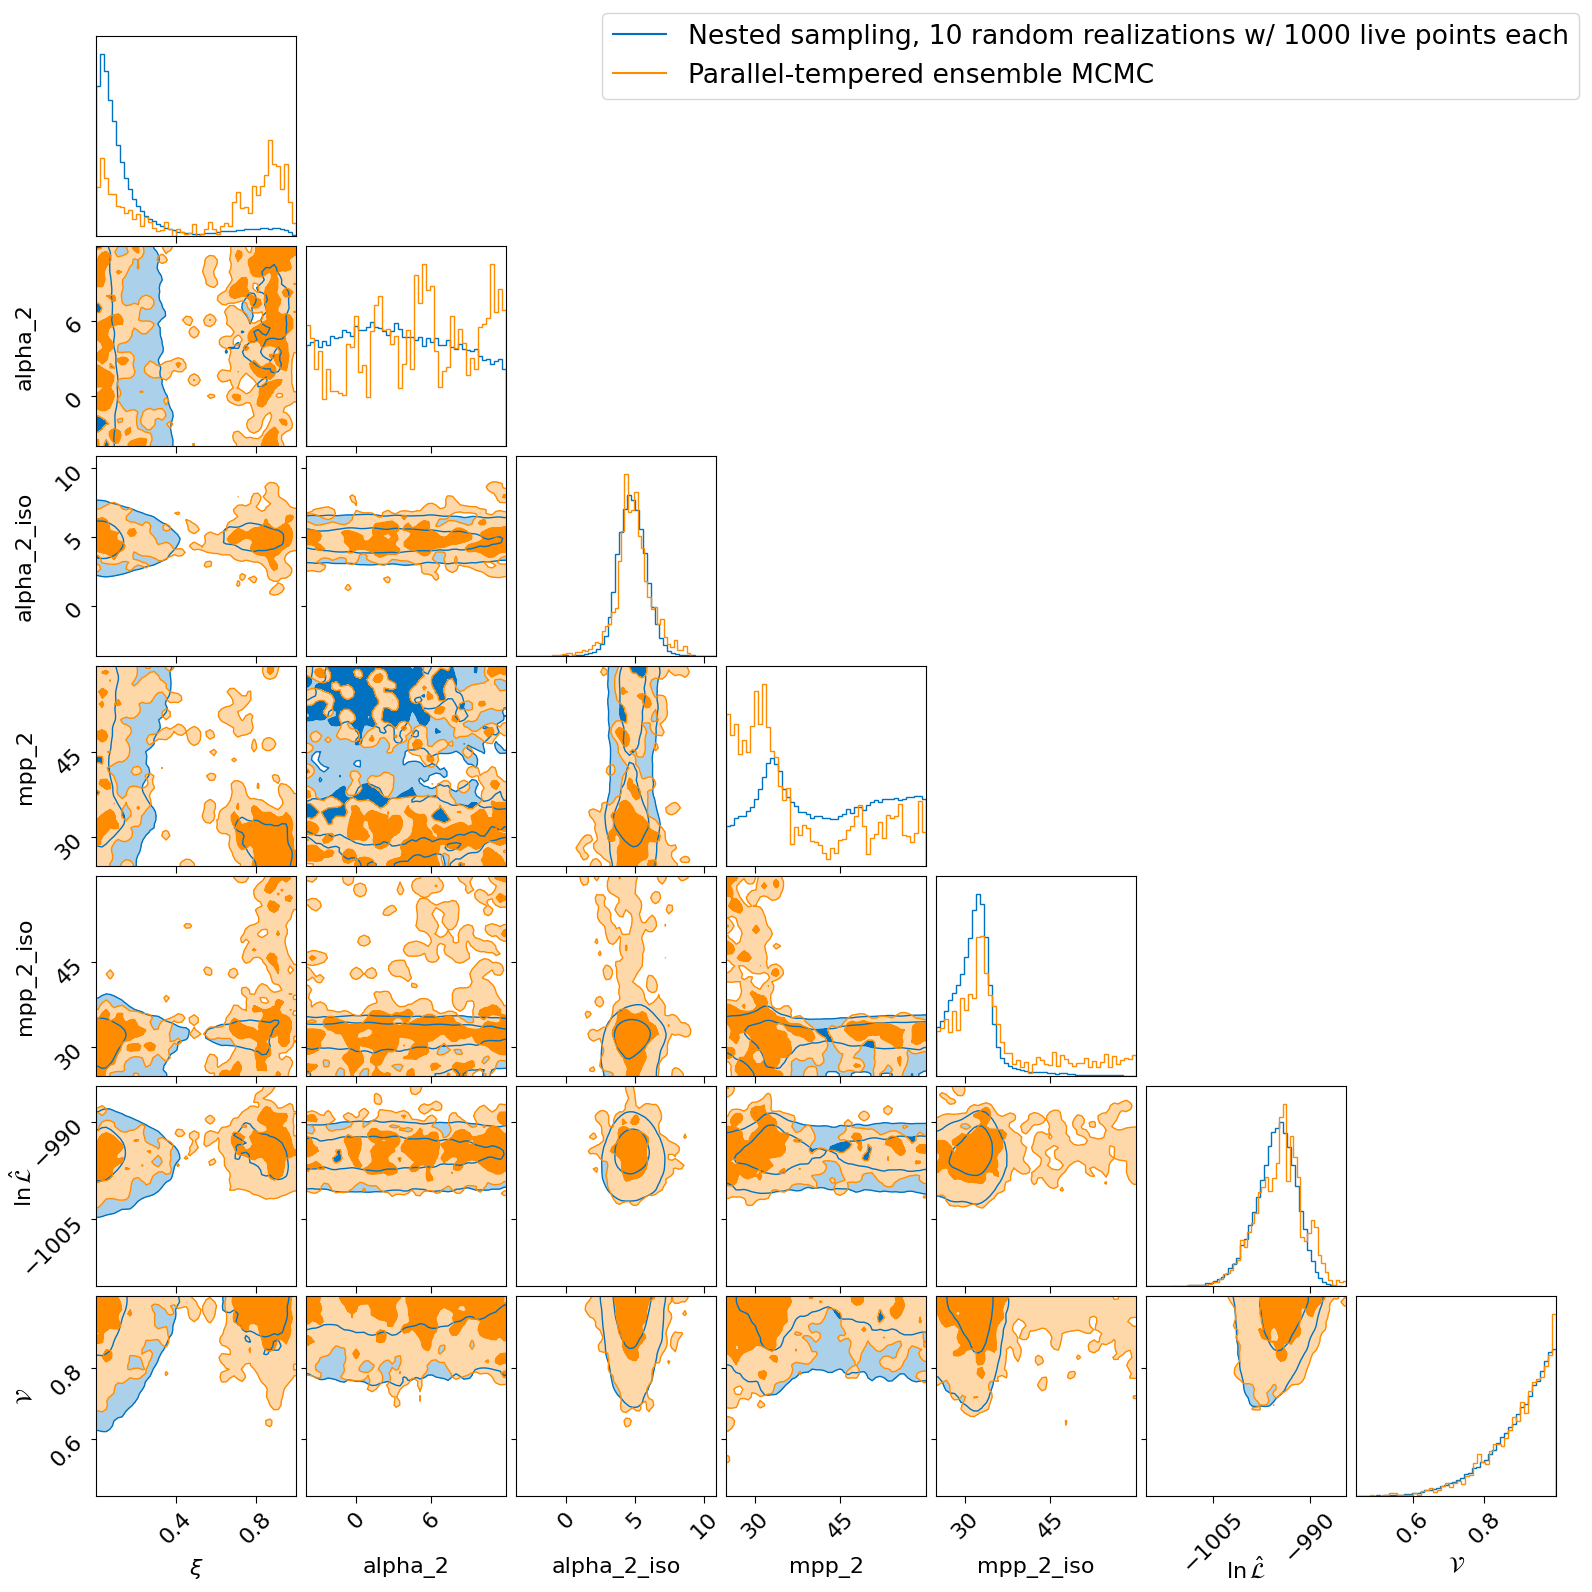

In [30]:
keys = ['weight_a', 'alpha_2', 'alpha_2_iso', 'mpp_2', 'mpp_2_iso', 'log_likelihood', 'variance']

fig = plot_multiple(
    [twomass, twomass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

## Three mass models

Each subpopulation gets it own mass model with the functional form of the $\texttt{Broken power law plus two peaks}$

In [31]:
datadir = '../../data/inference/strong/multimass/noah/threemass'
threemass = h5ify.load(f'{datadir}/sampling_seed/merged.h5')

threemass_pt = h5ify.load(f'{datadir}/ptemcee-hybrid-var1/posterior.h5')

# load in the checkpoint file to check convergence criterion
with open(f'{datadir}/ptemcee-hybrid-var1/run_checkpoint_resume.pickle', 'rb') as f:
    ptemcee_checkpoint = pickle.load(f)

# NOTE: convergence with ptemcee is determined by the inter- and intra-chain variance
# characterized by Q (similar to the Gelman-Rubin statistic)
# Q ~ 1 indicates convergence
print('ptemcee achieved Q:', ptemcee_checkpoint['Q_list'][-1])

ptemcee achieved Q: 1.0018539143520888


Again, based on the plot below, it's clear the MCMC is *not* converged, despite what Q says. Possible we need to tune other convergence criteria like the maximum allowed autocorrelation time, or just run with more walkers.

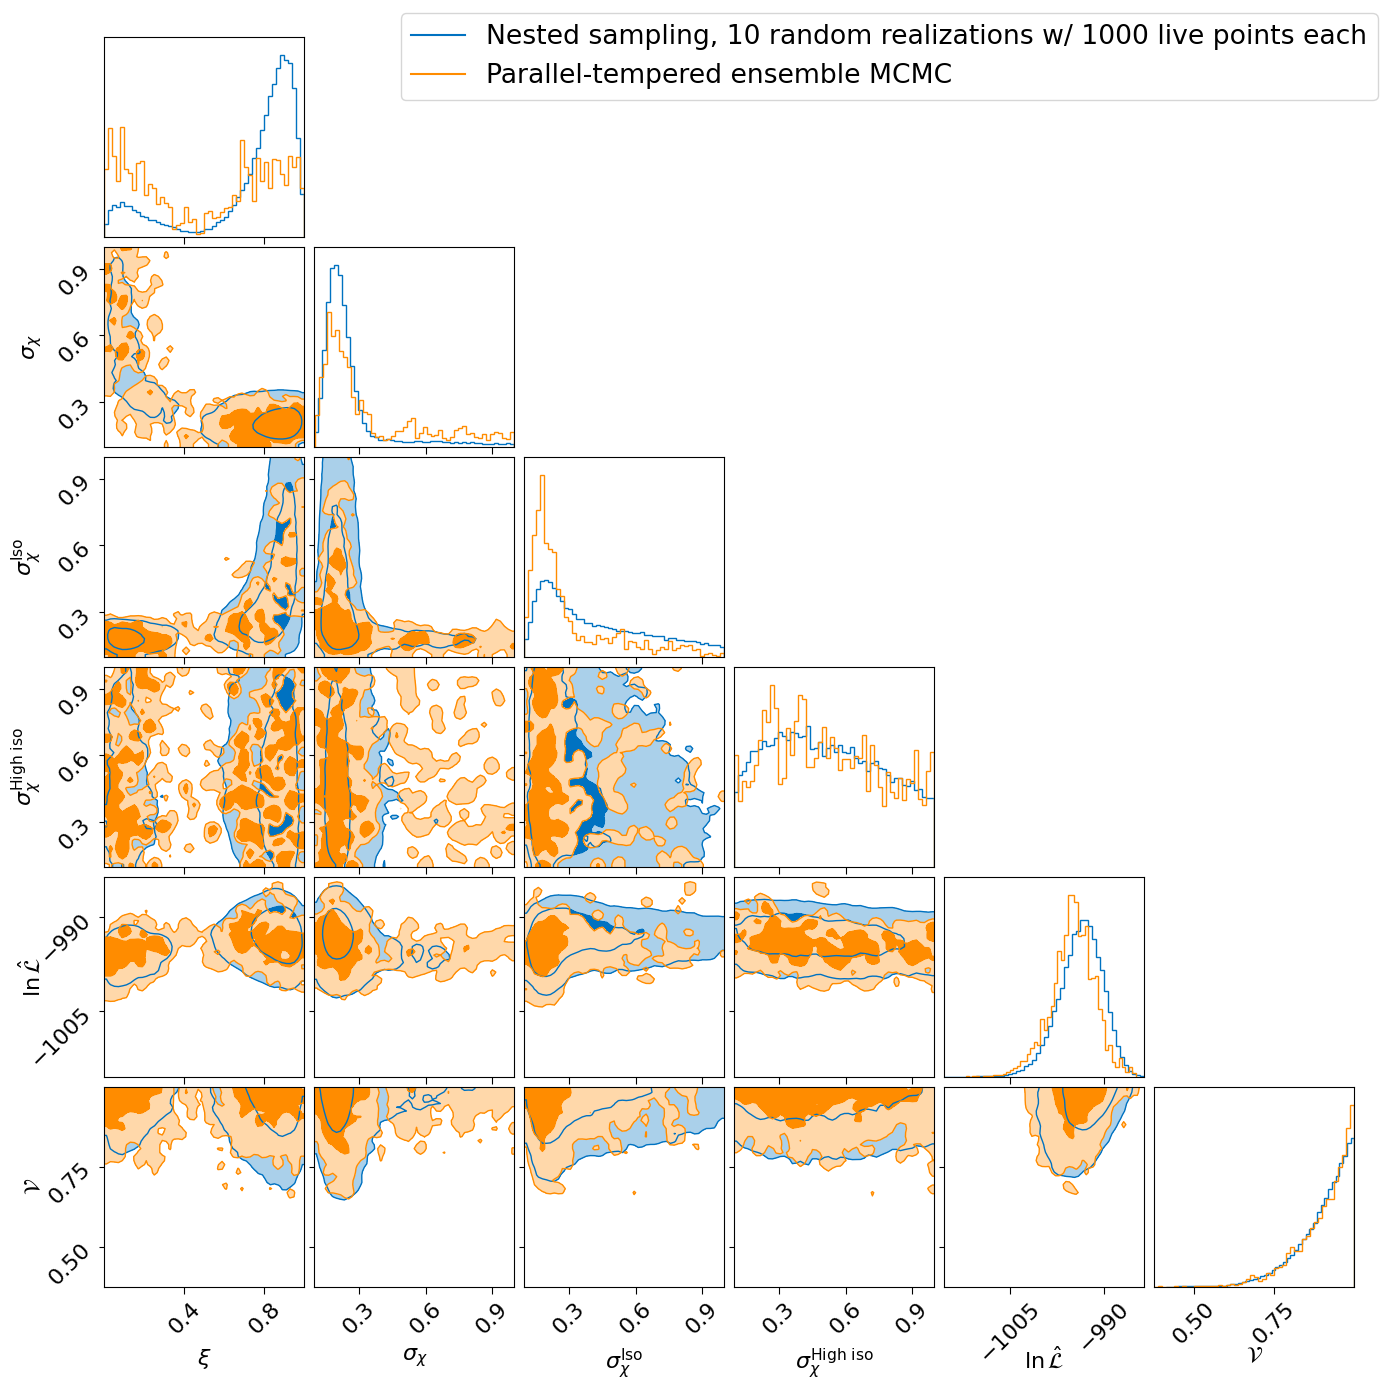

In [32]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

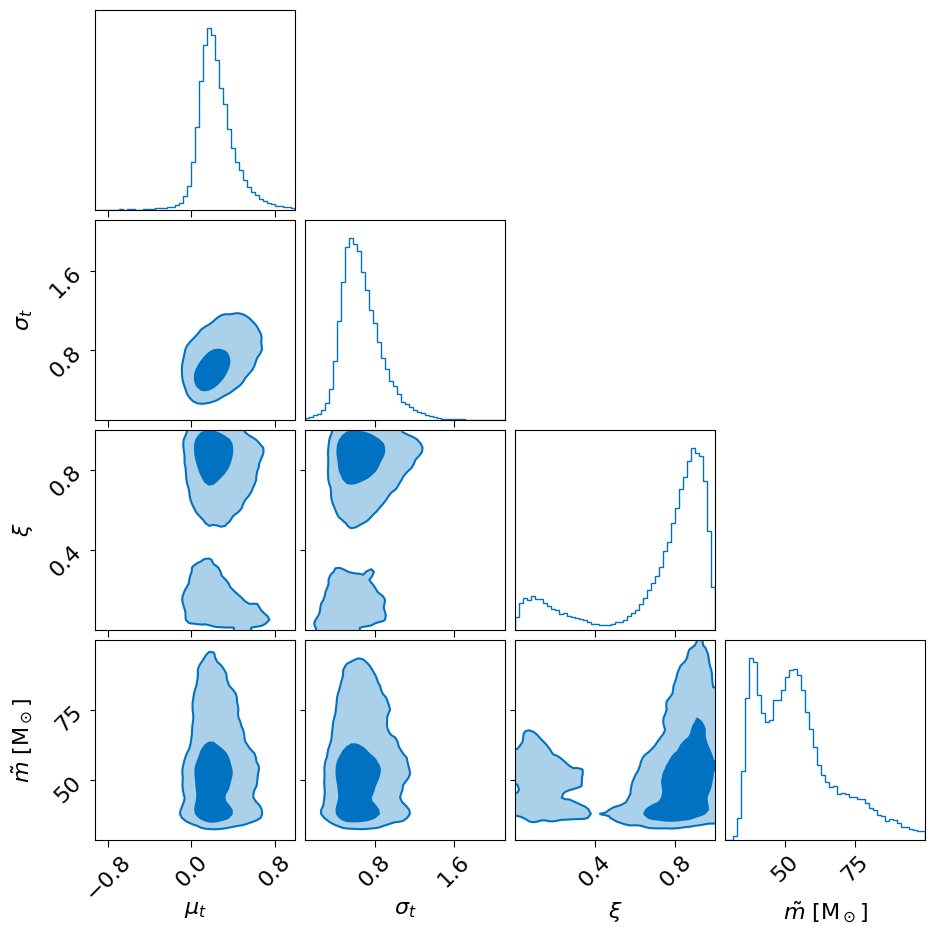

In [34]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut']

fig = plot_corner(
    threemass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

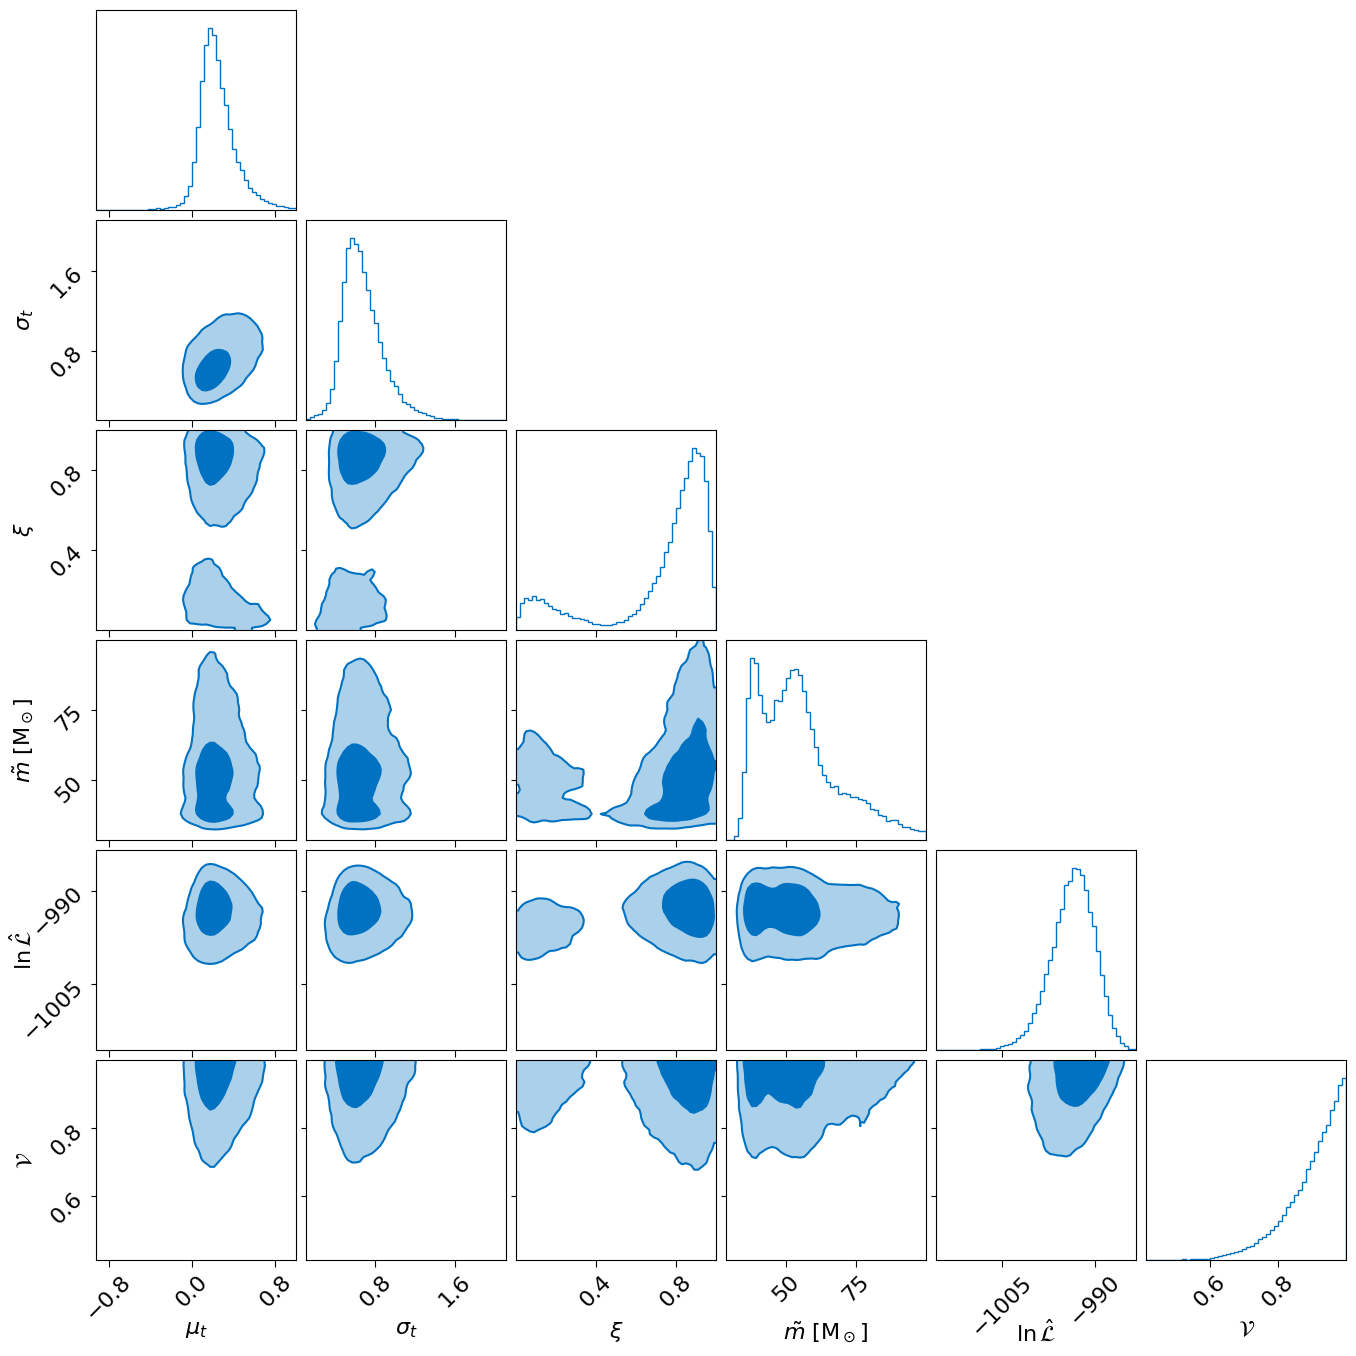

In [35]:
keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut', 'log_likelihood', 'variance']

fig = plot_corner(
    threemass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

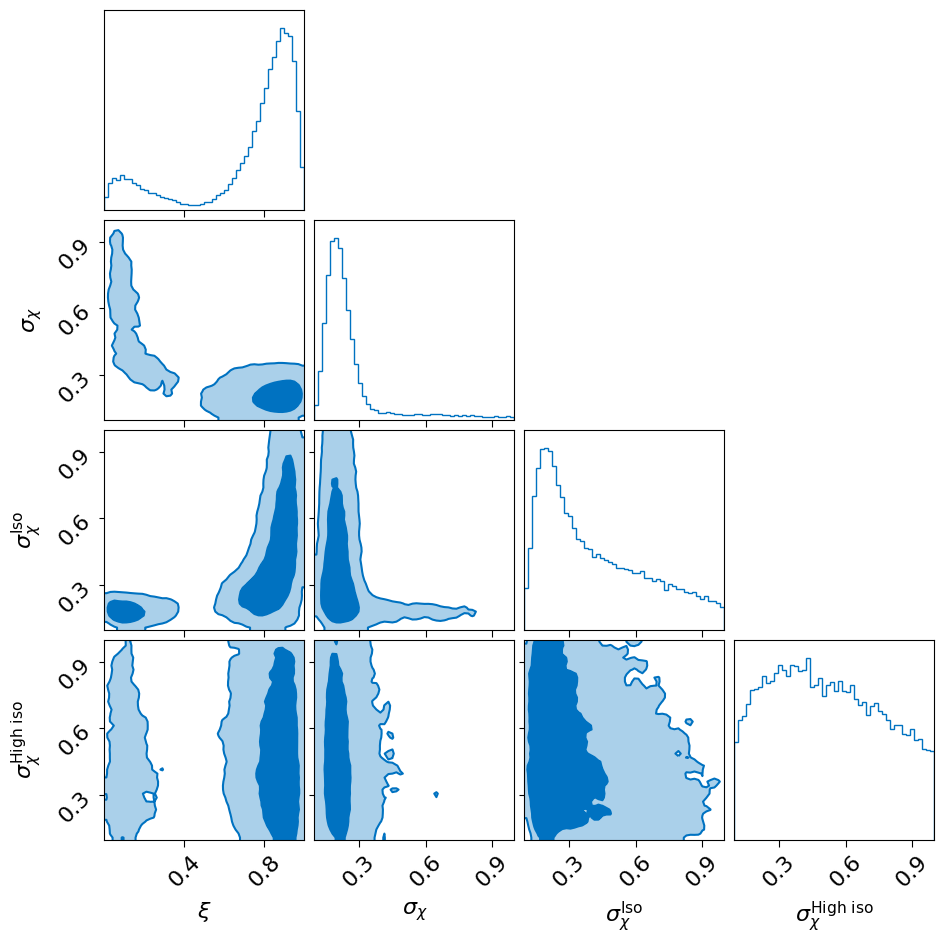

In [36]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3']

fig = plot_corner(
    threemass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

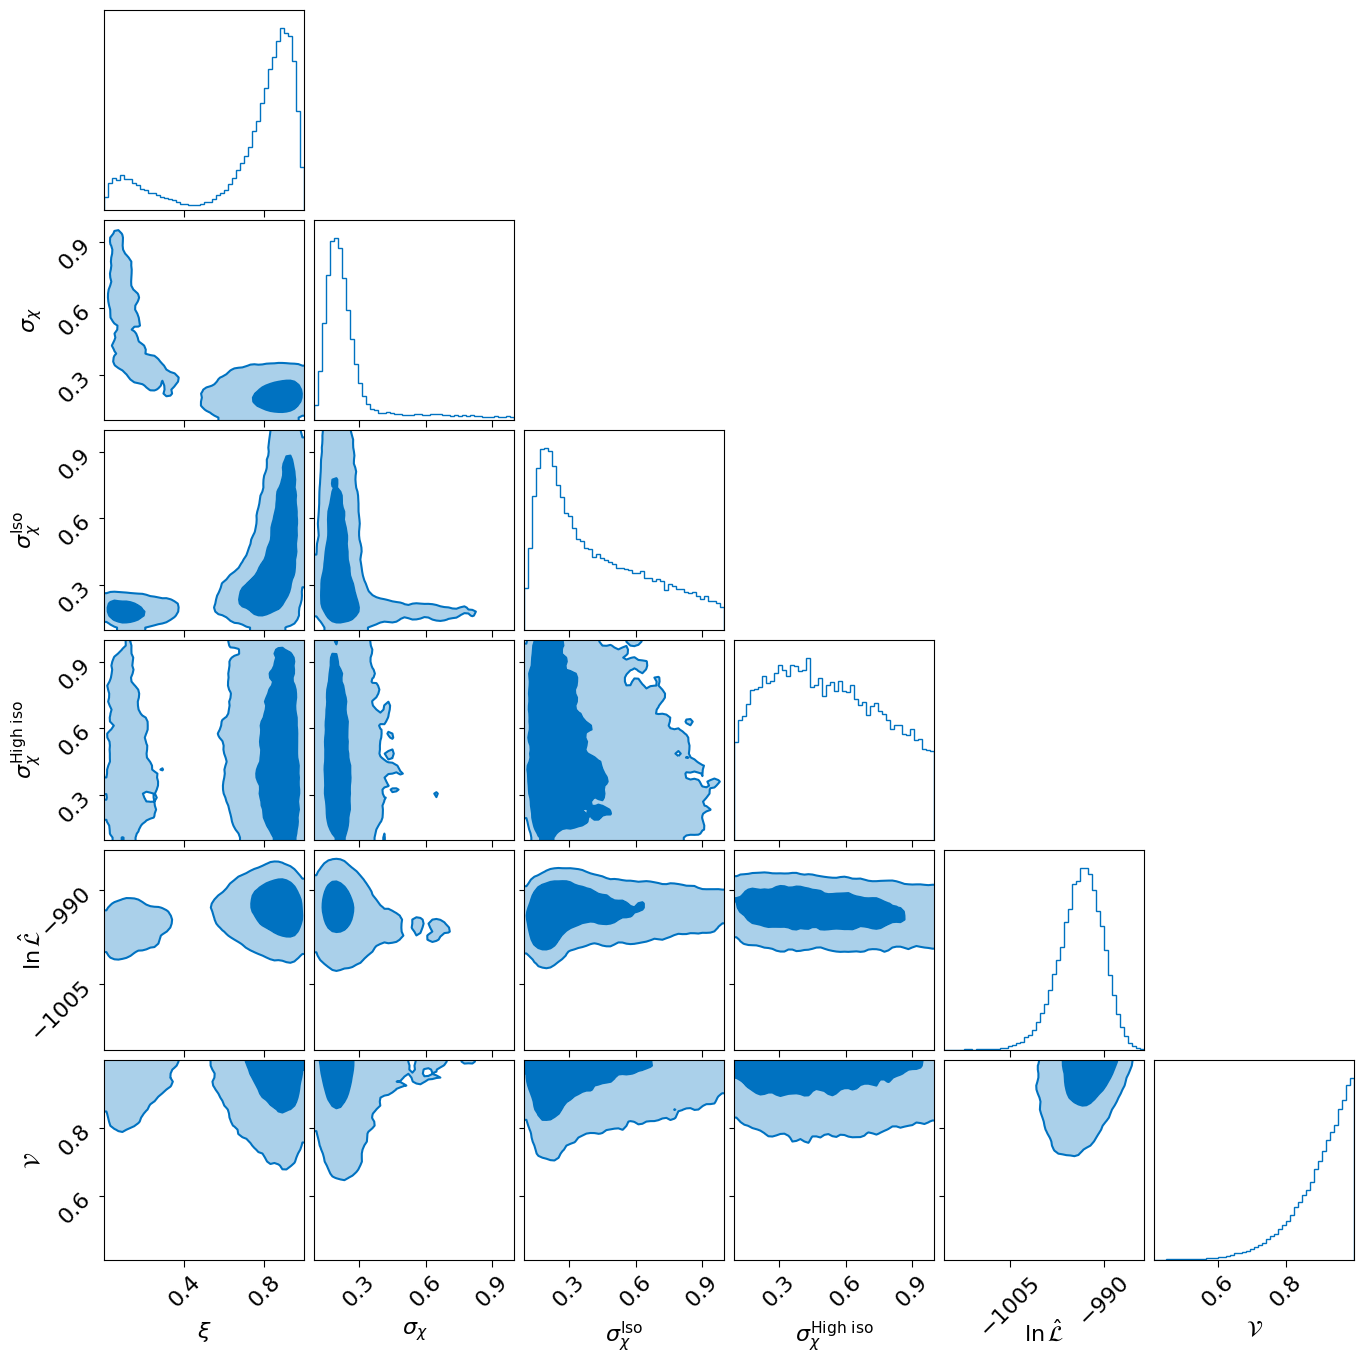

In [37]:
keys = ['weight_a', 'sigma_1', 'sigma_2', 'sigma_3', 'log_likelihood', 'variance']

fig = plot_corner(
    threemass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

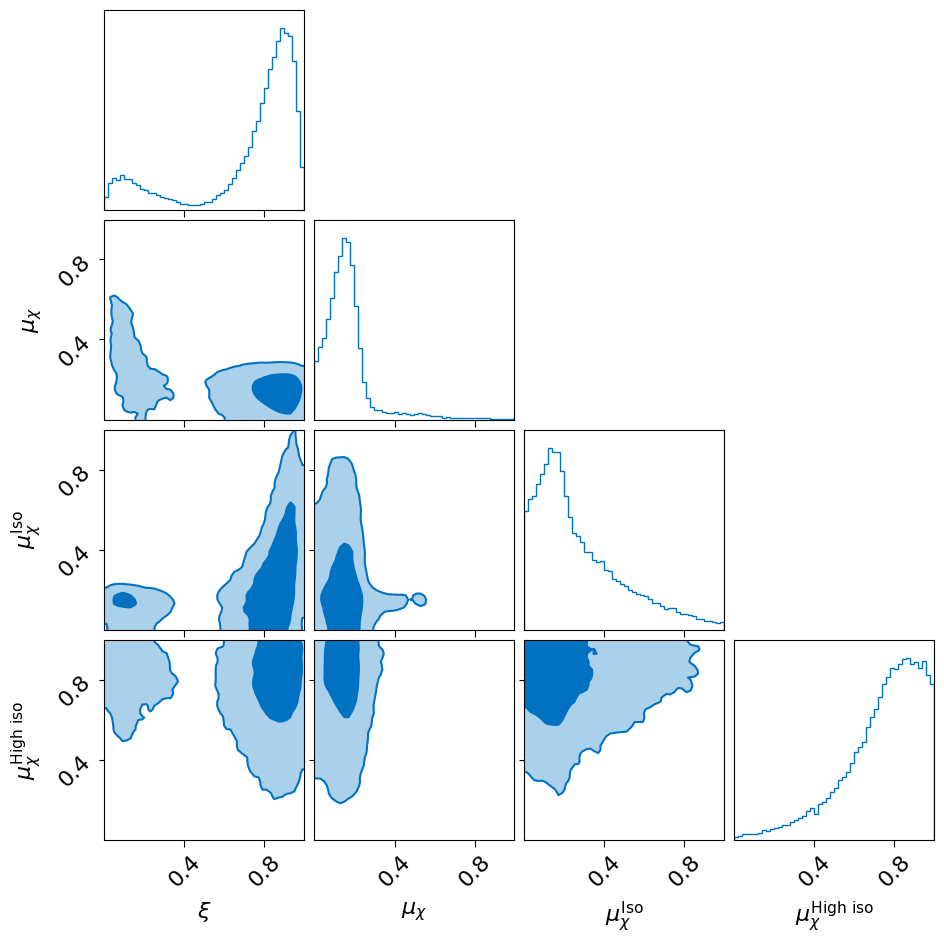

In [38]:
keys = ['weight_a', 'mu_1', 'mu_2', 'mu_3']

fig = plot_corner(
    threemass,
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
)

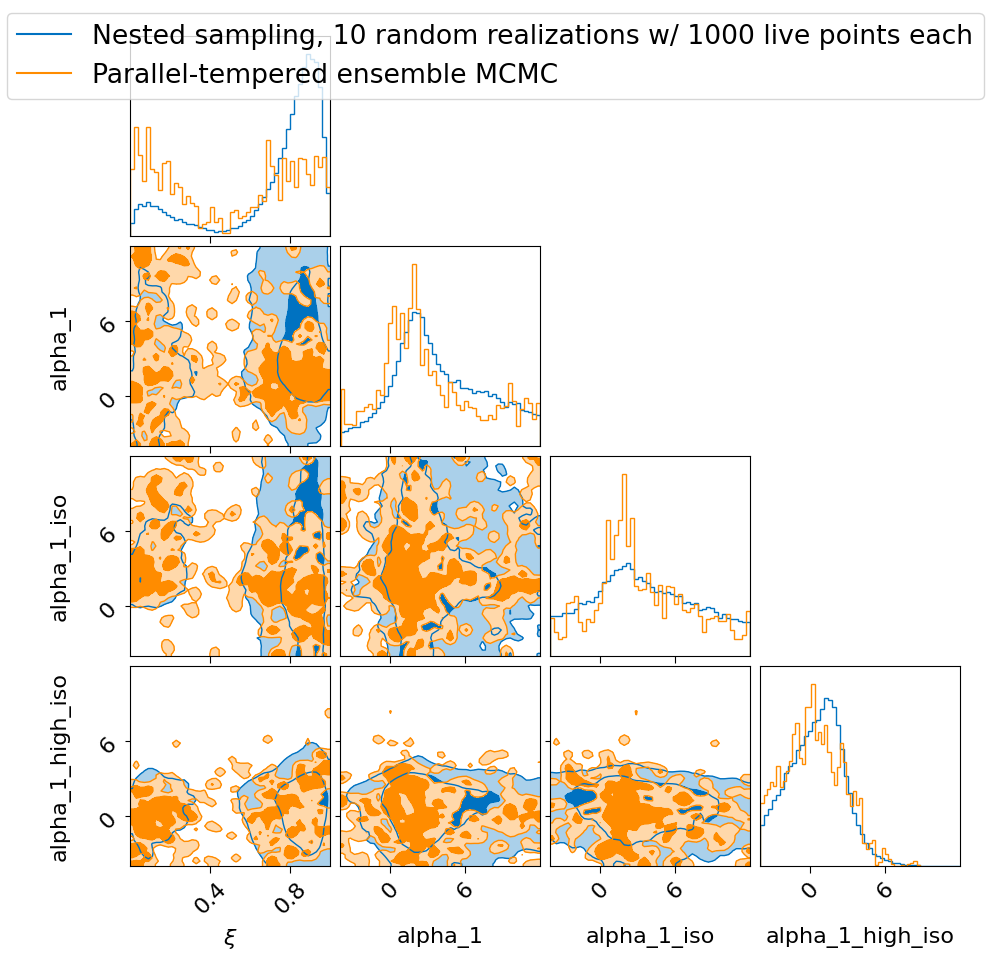

In [40]:
keys = ['weight_a', 'alpha_1', 'alpha_1_iso', 'alpha_1_high_iso']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

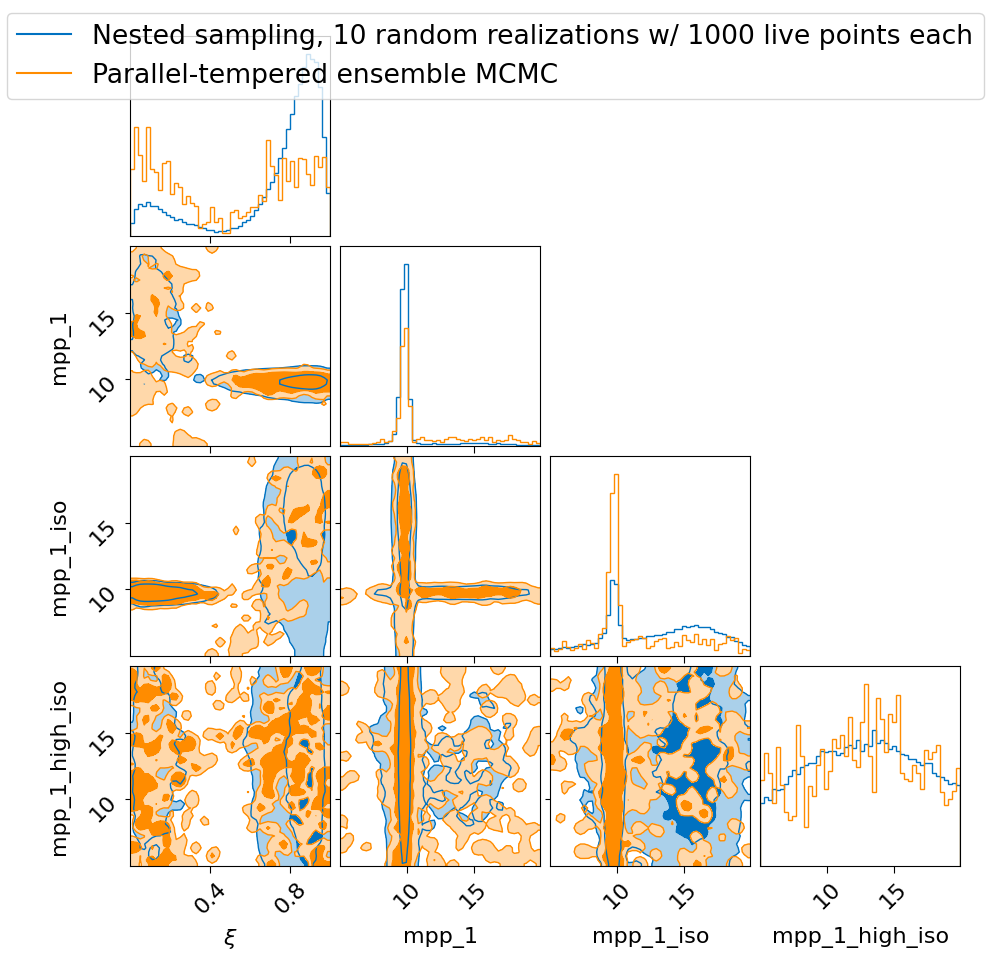

In [41]:
keys = ['weight_a', 'mpp_1', 'mpp_1_iso', 'mpp_1_high_iso']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

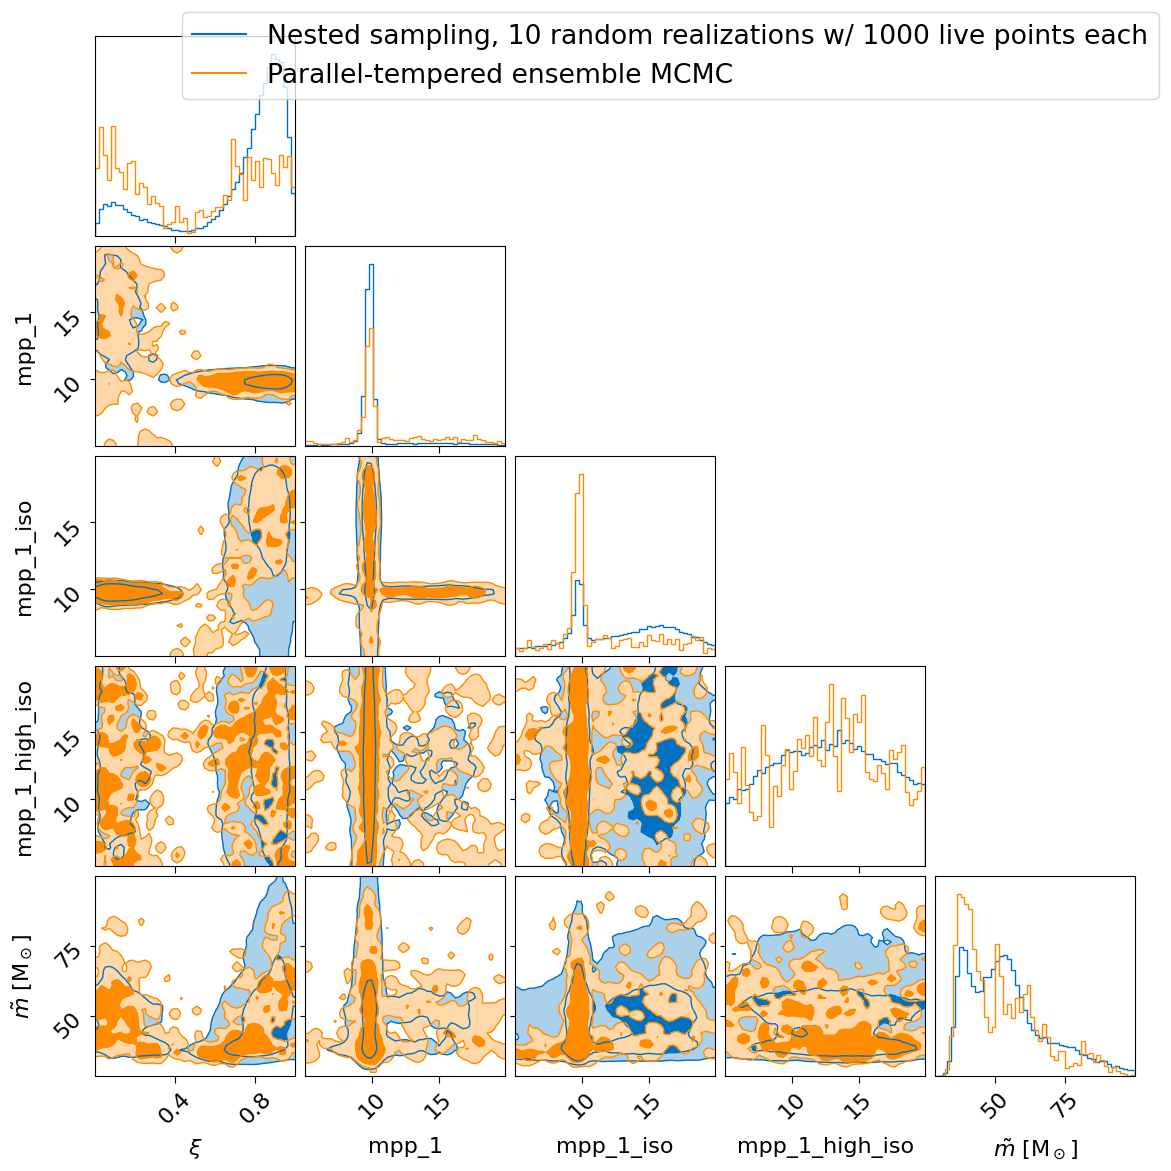

In [42]:
keys = ['weight_a', 'mpp_1', 'mpp_1_iso', 'mpp_1_high_iso', 'm_cut']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

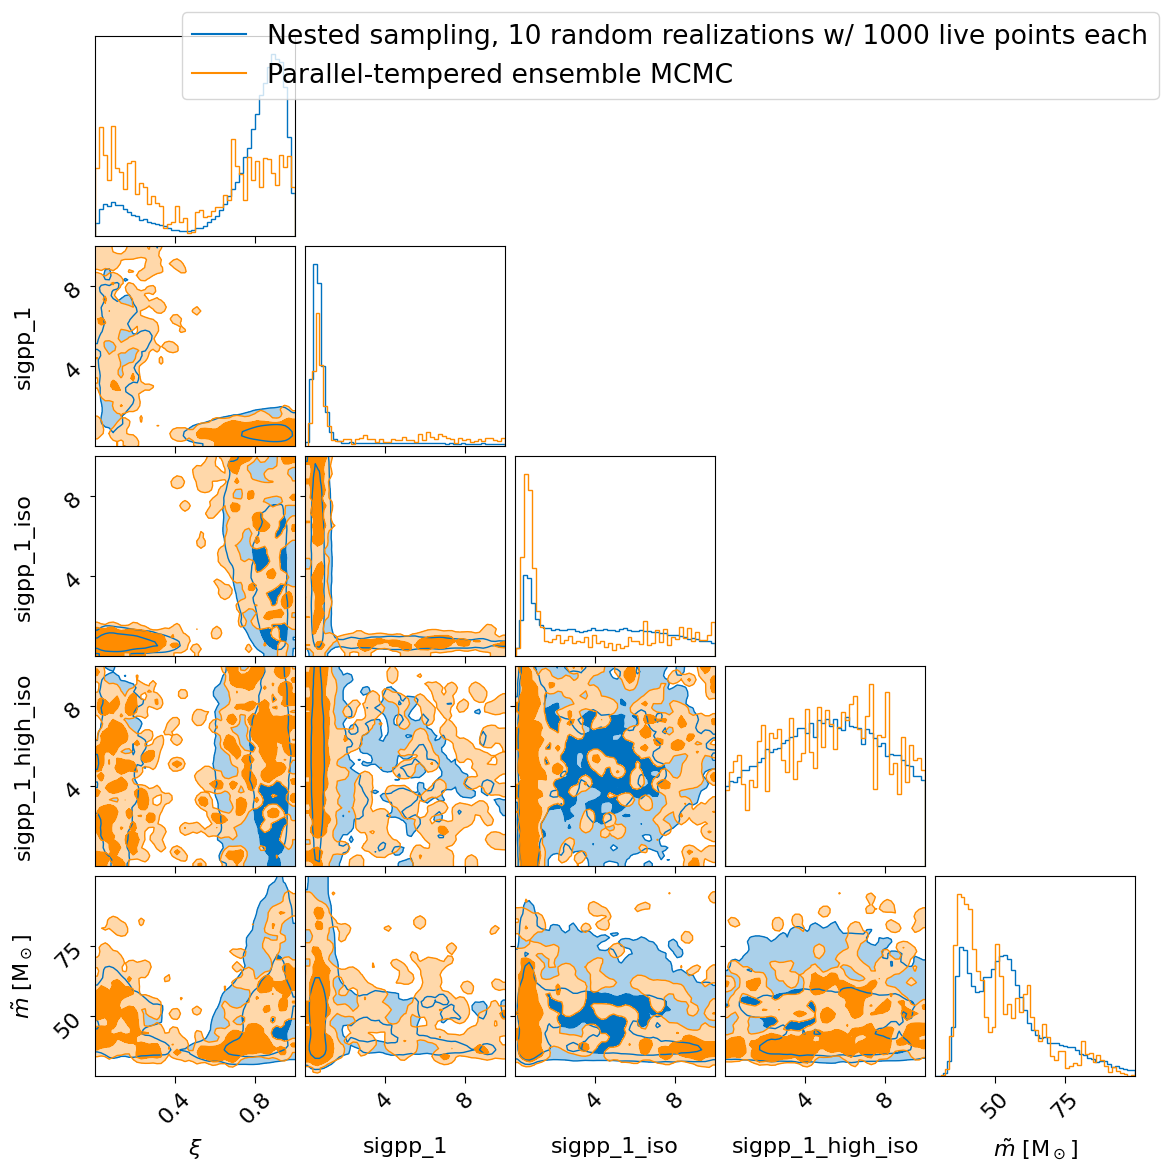

In [43]:
keys = ['weight_a', 'sigpp_1', 'sigpp_1_iso', 'sigpp_1_high_iso', 'm_cut']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

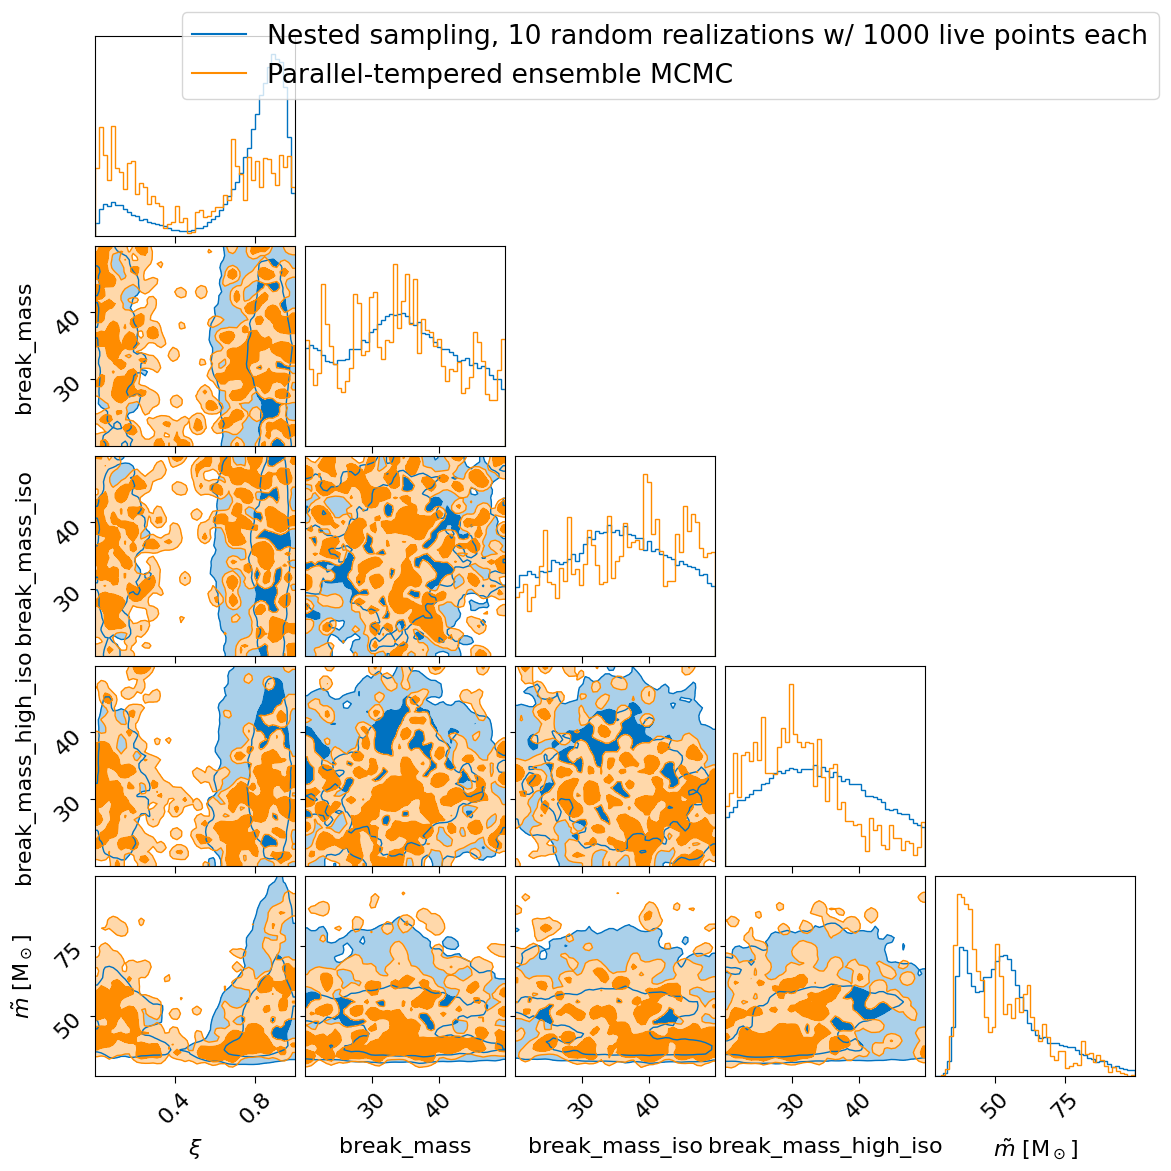

In [45]:
keys = ['weight_a', 'break_mass', 'break_mass_iso', 'break_mass_high_iso', 'm_cut']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)

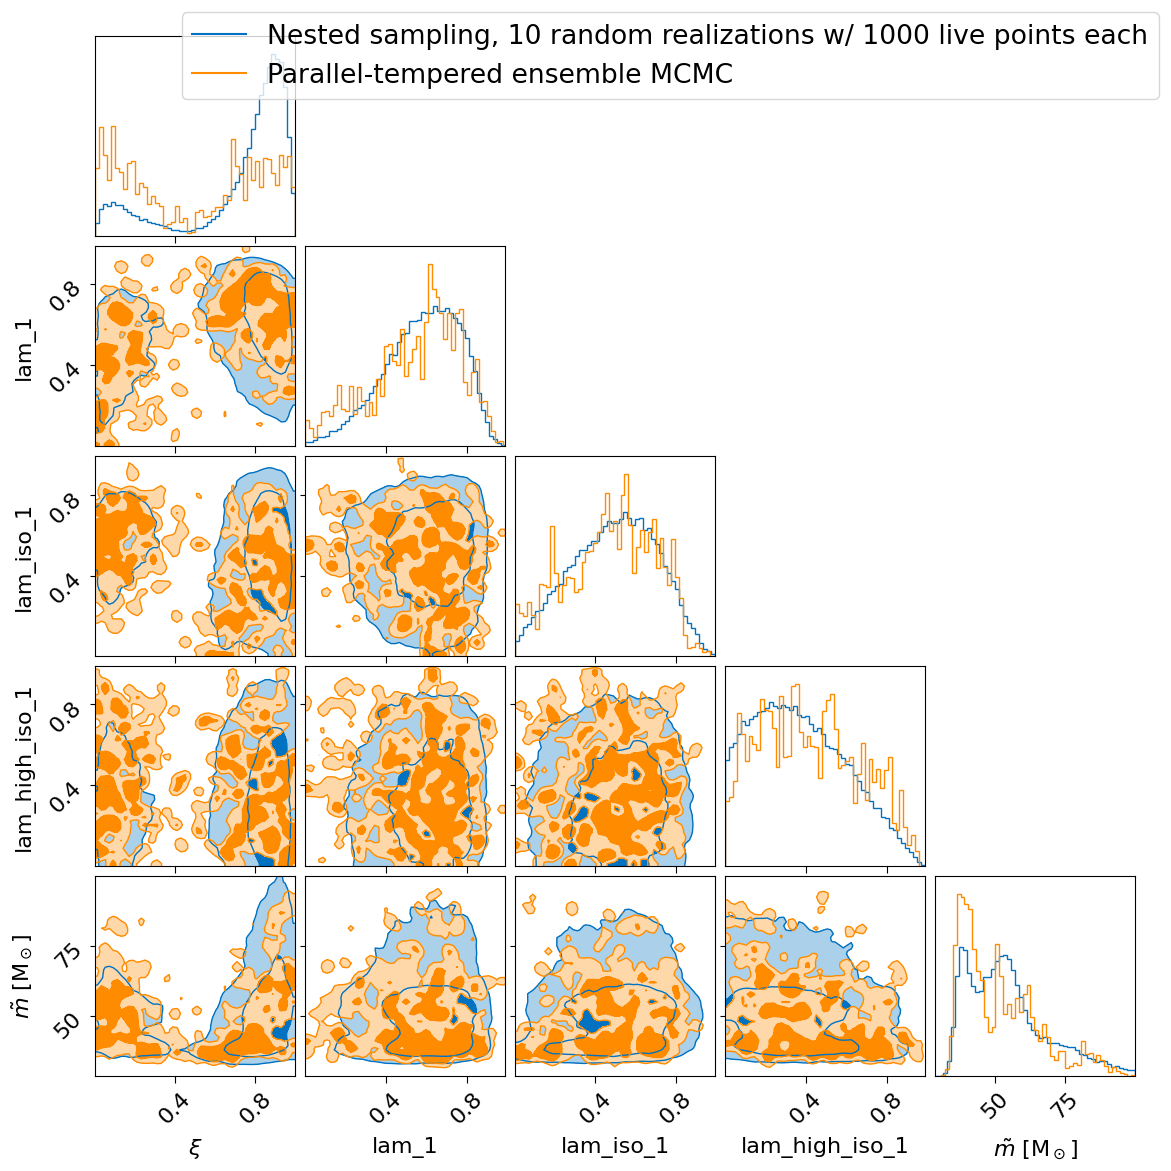

In [47]:
keys = ['weight_a', 'lam_1', 'lam_iso_1', 'lam_high_iso_1', 'm_cut']

fig = plot_multiple(
    [threemass, threemass_pt],
    labels={k : param_to_label.get(k, k) for k in keys},
    levels=(0.5, 0.9),
    plot_datapoints=False,
    xs_labels=[
        'Nested sampling, 10 random realizations w/ 1000 live points each',
        'Parallel-tempered ensemble MCMC'
    ],
)